# Load models and format

In [1]:
import torch
import pickle
import os
from pathlib import Path
from typing import Dict, List, Tuple
import torch.nn.functional as F

def load_activation_list(pkl_path: Path) -> List[Dict[int, torch.Tensor]]:
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    if not isinstance(data, list):
        raise ValueError(f"Expected a list from {pkl_path}, got {type(data)}")
    if len(data) == 0:
        raise ValueError(f"No entries in {pkl_path}")
    return data

def stack_data(data,
               normalize: bool = True,
               eps: float = 1e-8,):
    # shape metadata from first example
    first = data[0]
    layer_ids = sorted(first.keys())
    L = len(layer_ids)
    P, H = first[layer_ids[0]].shape  # [last_k, H]
    N = len(data)
    
    # allocate and fill
    X_lpnh = torch.empty(L, P, N, H, dtype=torch.float32)
    for li, L_id in enumerate(layer_ids):
        for n, ex in enumerate(data):
            x = ex[L_id].detach().to("cpu", dtype=torch.float32)  # [P, H]
            if normalize:
                # L2 normalize along hidden dim
                x = F.normalize(x, p=2, dim=-1, eps=eps)
            X_lpnh[li, :, n, :] = x

    return X_lpnh, layer_ids

In [314]:
lb_hf[0]

{0: tensor([[ 8.4229e-03,  6.5002e-03, -9.1553e-03,  ...,  2.0020e-02,
          -2.7161e-03, -1.0498e-02],
         [-7.6599e-03, -9.6436e-03, -2.1362e-03,  ...,  2.3499e-03,
           1.3428e-02,  1.0300e-03],
         [-3.0060e-03,  3.7537e-03,  2.7776e-05,  ...,  1.1978e-03,
           2.7847e-04,  2.8229e-03],
         [-1.3184e-02, -1.5015e-02, -1.6724e-02,  ...,  6.1951e-03,
           3.5667e-04,  3.6469e-03],
         [ 3.6774e-03, -3.3722e-03, -3.0899e-04,  ...,  8.2397e-03,
           1.9531e-03,  1.7319e-03]]),
 1: tensor([[ 0.0179,  0.0197,  0.0056,  ...,  0.0045,  0.0036, -0.0318],
         [ 0.0007, -0.0076, -0.0173,  ..., -0.0119,  0.0112, -0.0038],
         [-0.0092, -0.0001,  0.0141,  ..., -0.0196, -0.0005, -0.0007],
         [-0.0159, -0.0231, -0.0205,  ..., -0.0099,  0.0050, -0.0033],
         [-0.0021,  0.0004, -0.0122,  ...,  0.0081, -0.0020,  0.0138]]),
 2: tensor([[ 0.0159,  0.0092, -0.0105,  ..., -0.0224,  0.0036, -0.0280],
         [-0.0055,  0.0015,  0.0030,

In [223]:
# llama 3.1 8b base
lb_hf = load_activation_list("/media/anna/Samsung_T5/alignment/act_store/Meta-Llama-3.1-8B/harmful_activations.pkl")
lb_hl = load_activation_list("/media/anna/Samsung_T5/alignment/act_store/Meta-Llama-3.1-8B/harmless_activations.pkl")

lb_hf_stack, lb_layer_ids = stack_data(lb_hf, normalize = False)
lb_hl_stack, _ = stack_data(lb_hl, normalize = False)

# only important for cosine sims
# lb_hf_stack_norm, _ = stack_data(lb_hf)
# lb_hl_stack_norm, _ = stack_data(lb_hl)

In [205]:
# llama 3.1 8b instruct
li_hf = load_activation_list("/media/anna/Samsung_T5/alignment/act_store/Meta-Llama-3.1-8B-Instruct/harmful_activations.pkl")
li_hl = load_activation_list("/media/anna/Samsung_T5/alignment/act_store/Meta-Llama-3.1-8B-Instruct/harmless_activations.pkl")

li_hf_stack, li_layer_ids = stack_data(li_hf, normalize = False)
li_hl_stack, _ = stack_data(li_hl, normalize = False)

# only important for cosine sims
# li_hf_stack_norm, _ = stack_data(li_hf)
# li_hl_stack_norm, _ = stack_data(li_hl)

In [217]:
# oss 20b
oss_hf = load_activation_list("/media/anna/Samsung_T5/alignment/act_store/gpt-oss-20b/harmful_activations.pkl")
oss_hl = load_activation_list("/media/anna/Samsung_T5/alignment/act_store/gpt-oss-20b/harmless_activations.pkl")

oss_hf_stack, oss_layer_ids = stack_data(oss_hf, normalize = False)
oss_hl_stack, _ = stack_data(oss_hl, normalize = False)

# only important for cosine sims
# oss_hf_stack_norm, _ = stack_data(oss_hf)
# oss_hl_stack_norm, _ = stack_data(oss_hl)

In [220]:
# mixtral8x7B instruct
mix_hf = load_activation_list("/media/anna/Samsung_T5/alignment/act_store/Mixtral-8x7B-Instruct-v0.1/harmful_activations.pkl")
mix_hl = load_activation_list("/media/anna/Samsung_T5/alignment/act_store/Mixtral-8x7B-Instruct-v0.1/harmless_activations.pkl")

mix_hf_stack, mix_layer_ids = stack_data(mix_hf, normalize = False)
mix_hl_stack, _ = stack_data(mix_hl, normalize = False)

# only important for cosine sims
# mix_hf_stack_norm, _ = stack_data(mix_hf)
# mix_hl_stack_norm, _ = stack_data(mix_hl)

# Cosine Similarity Calculate and Compare

## implementation

In [3]:
def mean_intra_cosine_normalized(X: torch.Tensor) -> torch.Tensor:
    """
    X: [N, H], assumed L2-normalized on dim=-1
    Returns scalar tensor (mean pairwise cosine within set)
    """
    N = X.shape[0]
    if N < 2:
        return torch.tensor(float('nan'), dtype=X.dtype, device=X.device)
    s = X.sum(0)           # [H]
    return (s.dot(s) - N) / (N * (N - 1))

def mean_inter_cosine_normalized(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    """
    A: [N_a, H], B: [N_b, H], both L2-normalized
    """
    Na, Nb = A.shape[0], B.shape[0]
    if Na == 0 or Nb == 0:
        return torch.tensor(float('nan'), dtype=A.dtype, device=A.device)
    sa, sb = A.sum(0), B.sum(0)
    return sa.dot(sb) / (Na * Nb)

def inter_intra_means_per_layer_pos(X_h: torch.Tensor, X_s: torch.Tensor):
    """
    X_h: [L,P,Nh,H] harmful
    X_s: [L,P,Ns,H] safe/harmless
    Returns:
      mean_intra_h[L,P], mean_intra_s[L,P], mean_inter[L,P]
    """
    L, P, Nh, H = X_h.shape
    Ns = X_s.shape[2]

    # normalize along H
    X_hn = F.normalize(X_h, p=2, dim=-1)
    X_sn = F.normalize(X_s, p=2, dim=-1)

    mean_intra_h = torch.empty(L, P)
    mean_intra_s = torch.empty(L, P)
    mean_inter   = torch.empty(L, P)

    for li in range(L):
        for pi in range(P):
            Hset = X_hn[li, pi]  # [Nh, H]
            Sset = X_sn[li, pi]  # [Ns, H]
            mean_intra_h[li, pi] = mean_intra_cosine_normalized(Hset)
            mean_intra_s[li, pi] = mean_intra_cosine_normalized(Sset)
            mean_inter[li, pi]   = mean_inter_cosine_normalized(Hset, Sset)

    return mean_intra_h, mean_intra_s, mean_inter

In [153]:
import math
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, List

def _compute_shared_ylim(arrs, pad=0.02):
    vals = np.concatenate([a.reshape(-1) for a in arrs if a is not None])
    vmin, vmax = float(vals.min()), float(vals.max())
    # Cosine is in [-1, 1], but we clamp to data range with a small pad
    rng = max(1e-6, vmax - vmin)
    return vmin - pad * rng, vmax + pad * rng

def plot_cosines_by_layer(
    mean_intra_h,    # Tensor/ndarray [L, P]
    mean_intra_s,    # Tensor/ndarray [L, P]
    mean_inter,      # Tensor/ndarray [L, P]
    layer_ids: Optional[List[int]] = None,  # if provided, len == L; used for x-axis
    pos_labels: Optional[List[str]] = None, # optional labels per token position (len P)
    figsize=(8, 4.5)
):
    """
    Makes three separate figures (no subplots):
      1) Intra-harmful, 2) Intra-harmless, 3) Inter-group
    Each figure: x=layers, y=cosine similarity; one line per token position.
    Colors are consistent across the three figures by plotting positions in the same order.
    """
    # convert to numpy (keeps order and values)
    H = np.asarray(mean_intra_h)
    S = np.asarray(mean_intra_s)
    I = np.asarray(mean_inter)
    assert H.ndim == S.ndim == I.ndim == 2, "All inputs must be [L, P]"

    L, P = H.shape
    assert S.shape == (L, P) and I.shape == (L, P)

    if layer_ids is None:
        x = np.arange(L)
        x_label = "Layer (index)"
    else:
        assert len(layer_ids) == L
        x = np.asarray(layer_ids)
        x_label = "Layer (id)"

    if pos_labels is None:
        # Default labels: pos 0..P-1. If these are "last_k", you can pass e.g. ["t=-5",..., "t=-1"] instead.
        pos_labels = [f"pos {p}" for p in range(P)]

    # shared y-limits across all three figures
    ylo, yhi = _compute_shared_ylim([H, S, I])

    def _plot_one(Y, title):
        plt.figure(figsize=figsize)
        for p in range(P):
            # Plot positions in the same order across figures to keep color mapping consistent
            plt.plot(x, Y[:, p], label=pos_labels[p])
        plt.title(title)
        plt.xlabel(x_label)
        plt.ylabel("Cosine similarity")
        plt.ylim(ylo, yhi)
        # Clean tick density for many layers
        if L > 40:
            # show ~20 ticks
            step = max(1, L // 20)
            plt.xticks(x[::step])
        plt.legend(loc="best")
        plt.grid(True, linewidth=0.5, alpha=0.3)
        plt.tight_layout()
        plt.show()

    _plot_one(H, "Intra-group (Harmful)")
    _plot_one(S, "Intra-group (Harmless)")
    _plot_one(I, "Inter-group (Harmful ↔ Harmless)")

In [5]:
import pandas as pd

def summarize_cosine_hierarchy(mean_intra_h, mean_intra_s, mean_inter):
    """
    Computes difference metrics and summary statistics.
    Returns a dict + DataFrame for per-(layer,pos) inspection.
    """
    d1 = mean_intra_h - mean_intra_s  # harmful minus harmless
    d2 = mean_intra_s - mean_inter    # harmless minus inter
    d3 = mean_intra_h - mean_inter    # harmful minus inter

    df = pd.DataFrame({
        "layer":  torch.arange(mean_intra_h.shape[0]).repeat(mean_intra_h.shape[1]).numpy(),
        "pos":    torch.arange(mean_intra_h.shape[1]).tile(mean_intra_h.shape[0]).numpy(),
        "delta_h_s": d1.flatten().numpy(),
        "delta_s_i": d2.flatten().numpy(),
        "delta_h_i": d3.flatten().numpy(),
        "intra_h": mean_intra_h.flatten().numpy(),
        "intra_s": mean_intra_s.flatten().numpy(),
        "inter":   mean_inter.flatten().numpy(),
    })

    stats = {
        "Δ(harmful - harmless)": {
            "mean": float(d1.mean()), "std": float(d1.std())
        },
        "Δ(harmless - inter)": {
            "mean": float(d2.mean()), "std": float(d2.std())
        },
        "Δ(harmful - inter)": {
            "mean": float(d3.mean()), "std": float(d3.std())
        }
    }

    return stats, df

In [222]:
def cosine_sim_run(hf_stack_norm, hl_stack_norm, layer_ids, pos_k = 5):
    intra_hf, intra_hl, inter = inter_intra_means_per_layer_pos(hf_stack_norm, hl_stack_norm)
    pos_labels = [f"t=-{5- p}" for p in range(pos_k)]
    
    plot_cosines_by_layer(intra_hf, intra_hl, inter,
                          layer_ids=layer_ids, pos_labels=pos_labels)
    
    stats, df = summarize_cosine_hierarchy(intra_hf, intra_hl, inter)
    print(stats)
    
    ordering_correct = ((intra_hf > intra_hl) & 
                        (intra_hl > inter))
    ordering_accuracy = ordering_correct.float().mean().item()
    print(f"Ordering holds in {ordering_accuracy*100:.1f}% of (layer, position) pairs")
    
    hf_over_i = (intra_hf > inter).float().mean().item()
    print(f"Harmful > Inter in {hf_over_i*100}% of (layer, position) pairs")
    return stats, df

## results

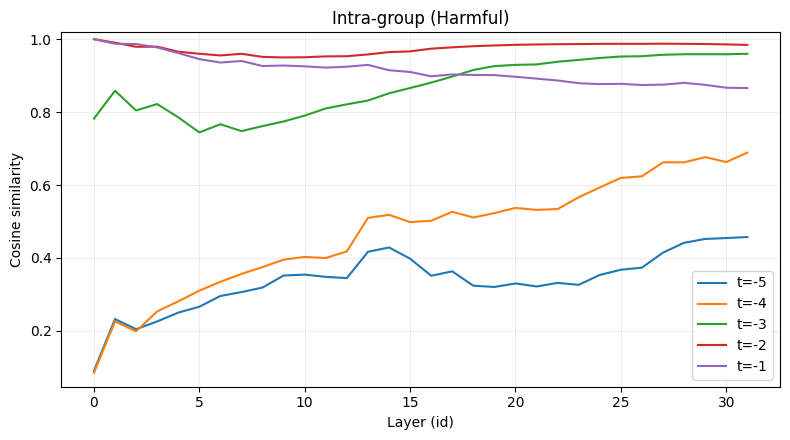

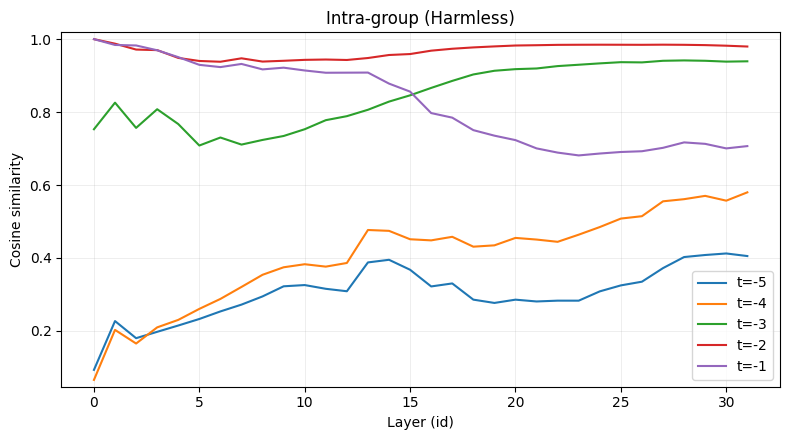

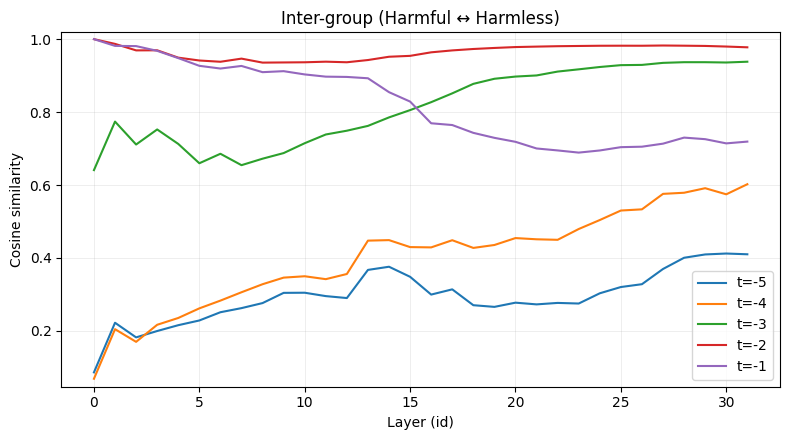

{'Δ(harmful - harmless)': {'mean': 0.043879635632038116, 'std': 0.04950631409883499}, 'Δ(harmless - inter)': {'mean': 0.009959491901099682, 'std': 0.018761593848466873}, 'Δ(harmful - inter)': {'mean': 0.053839124739170074, 'std': 0.046545978635549545}}
Ordering holds in 76.2% of (layer, position) pairs
Harmful > Inter in 98.7500011920929% of (layer, position) pairs


In [224]:
lb_cos_stats, lb_cos_df = cosine_sim_run(lb_hf_stack_norm, lb_hl_stack_norm, lb_layer_ids)

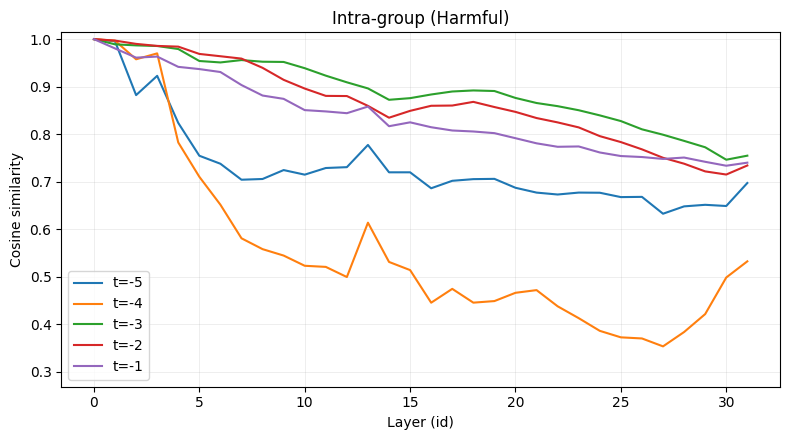

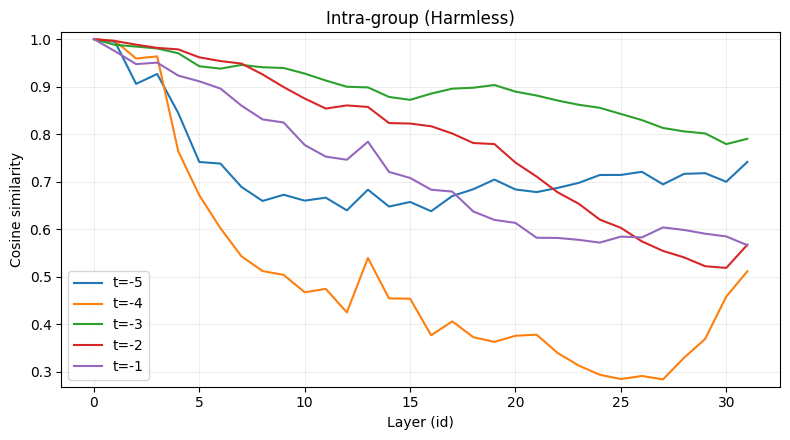

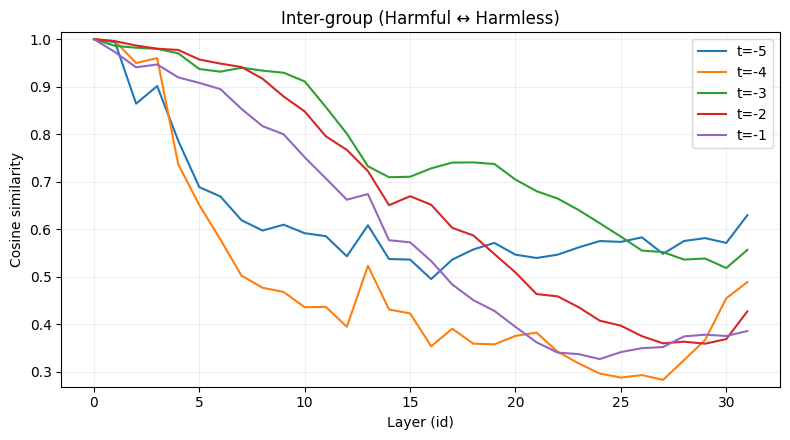

{'Δ(harmful - harmless)': {'mean': 0.04857553541660309, 'std': 0.06748098134994507}, 'Δ(harmless - inter)': {'mean': 0.09834028780460358, 'std': 0.08951722830533981}, 'Δ(harmful - inter)': {'mean': 0.14691582322120667, 'std': 0.1272374540567398}}
Ordering holds in 72.5% of (layer, position) pairs
Harmful > Inter in 98.1249988079071% of (layer, position) pairs


In [60]:
li_cos_stats, li_cos_df = cosine_sim_run(li_hf_stack_norm, li_hl_stack_norm, li_layer_ids)

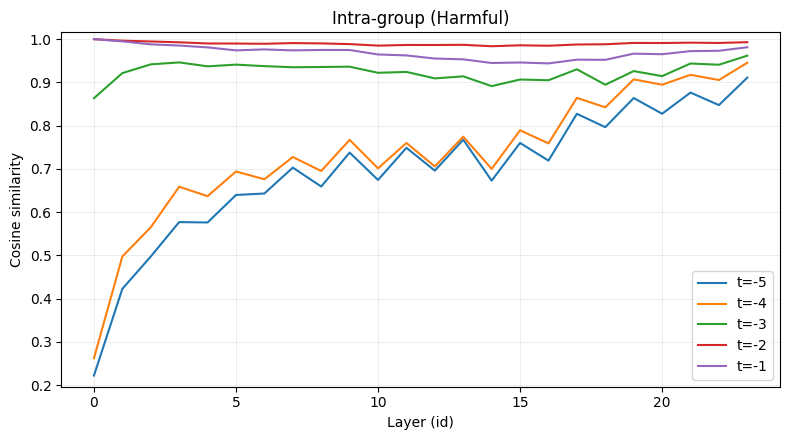

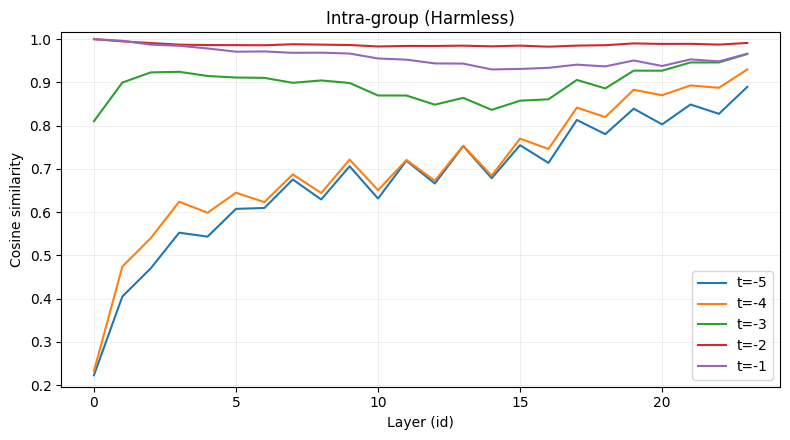

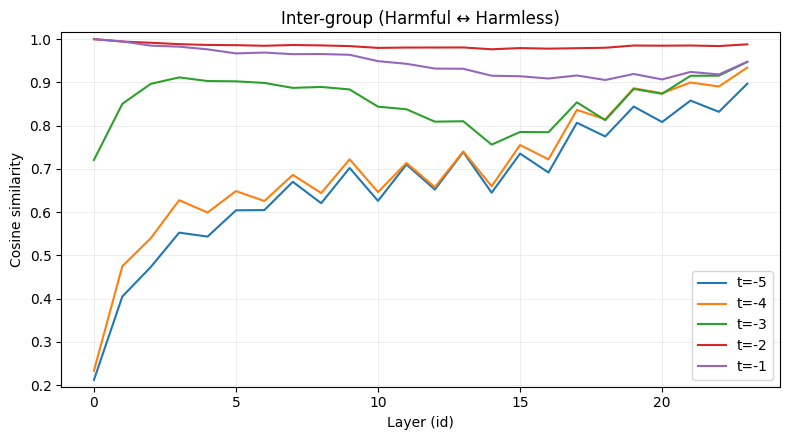

{'Δ(harmful - harmless)': {'mean': 0.01857629604637623, 'std': 0.016719453036785126}, 'Δ(harmless - inter)': {'mean': 0.012718765065073967, 'std': 0.01922723837196827}, 'Δ(harmful - inter)': {'mean': 0.031295061111450195, 'std': 0.028193742036819458}}
Ordering holds in 71.7% of (layer, position) pairs
Harmful > Inter in 98.33333492279053% of (layer, position) pairs


In [62]:
oss_cos_stats, oss_cos_df = cosine_sim_run(oss_hf_stack_norm, oss_hl_stack_norm, oss_layer_ids)

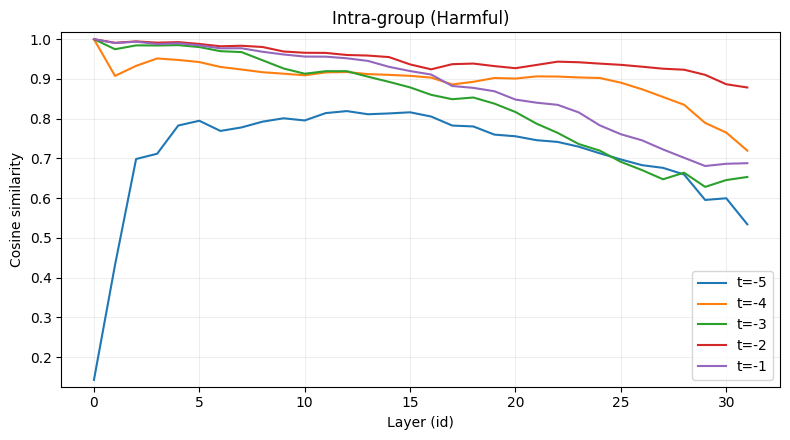

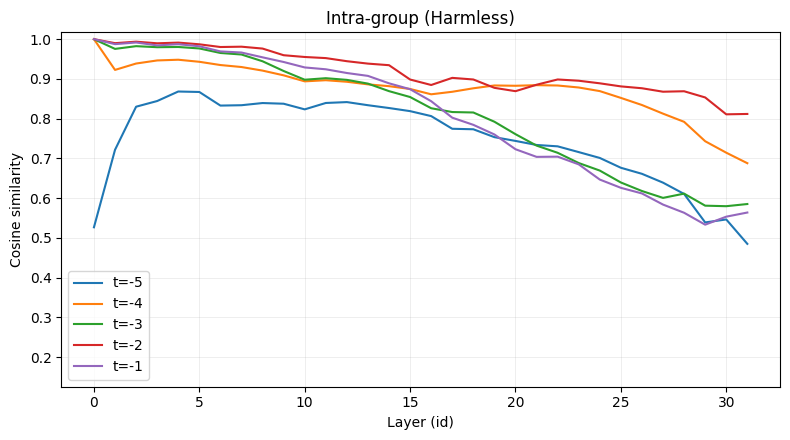

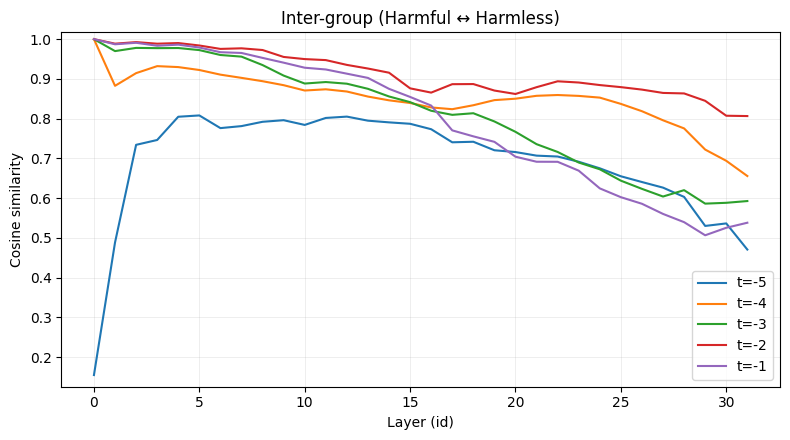

{'Δ(harmful - harmless)': {'mean': 0.02341691590845585, 'std': 0.06085340678691864}, 'Δ(harmless - inter)': {'mean': 0.019932355731725693, 'std': 0.03706018254160881}, 'Δ(harmful - inter)': {'mean': 0.04334926977753639, 'std': 0.04202942177653313}}
Ordering holds in 73.8% of (layer, position) pairs
Harmful > Inter in 92.5000011920929% of (layer, position) pairs


In [8]:
mix_cos_stats, mix_cos_df = cosine_sim_run(mix_hf_stack_norm, mix_hl_stack_norm, mix_layer_ids)

# Projection on Arditi Direction

## implementation

In [11]:
import json

def load_refusal(model_id):
    prefix = "/media/anna/Samsung_T5/alignment/runs/"+model_id
    refusal_dir = torch.load(prefix+"/direction.pt", map_location=torch.device('cpu'))
    with open(prefix+"/direction_metadata.json", "r") as js:
        refusal_meta = json.load(js)
    pos = refusal_meta["pos"]
    layer = refusal_meta["layer"]
    
    return (pos,layer), refusal_dir

def unit(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return x / (x.norm(p=2) + eps)

def cohen_d(x: np.ndarray, y: np.ndarray) -> float:
    # Pooled SD version
    nx, ny = len(x), len(y)
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    s = math.sqrt(((nx - 1)*vx + (ny - 1)*vy) / (nx + ny - 2))
    if s == 0:
        return float('nan')
    return (x.mean() - y.mean()) / s

def auc_from_scores(pos: np.ndarray, neg: np.ndarray) -> float:
    """
    AUROC where 'pos' are harmful scores and 'neg' are harmless scores.
    Uses the rank-sum formula (no heavy deps).
    """
    scores = np.concatenate([pos, neg])
    labels = np.concatenate([np.ones_like(pos, dtype=bool),
                             np.zeros_like(neg, dtype=bool)])
    order = np.argsort(scores, kind="mergesort")  # stable
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(scores) + 1)
    # average ranks for ties:
    # (mergesort keeps equal blocks contiguous; we correct by averaging)
    i = 0
    while i < len(scores):
        j = i + 1
        while j < len(scores) and scores[order[j]] == scores[order[i]]:
            j += 1
        if j - i > 1:
            avg = (i + 1 + j) / 2.0
            ranks[order[i:j]] = avg
        i = j
    n_pos = labels.sum()
    n_neg = (~labels).sum()
    sum_r_pos = ranks[labels].sum()
    auc = (sum_r_pos - n_pos*(n_pos + 1)/2.0) / (n_pos * n_neg)
    return float(auc)

@torch.no_grad()
def project_along_direction(
    X_h_lpnh: torch.Tensor,   # [L, P, N_h, H] (raw activations)
    X_s_lpnh: torch.Tensor,   # [L, P, N_s, H] (raw activations)
    layer_idx: int,
    pos_idx: int,
    w: torch.Tensor,          # [H] refusal direction (matching H)
    sign_align: bool = True,  # flip sign so harmful mean > harmless mean (for clarity)
):
    """
    Returns harmful and harmless projections (numpy arrays), plus a stats dict.
    """
    assert X_h_lpnh.shape[-1] == X_s_lpnh.shape[-1] == w.numel()
    u = unit(w.float().cpu())            # [H]
    Xh = X_h_lpnh[layer_idx, pos_idx]    # [N_h, H]
    Xs = X_s_lpnh[layer_idx, pos_idx]    # [N_s, H]

    # signed projections
    proj_h = (Xh @ u).cpu().numpy()
    proj_s = (Xs @ u).cpu().numpy()

    if sign_align and proj_h.mean() < proj_s.mean():
        proj_h = -proj_h
        proj_s = -proj_s

    stats = {
        "harmful": {
            "mean": float(proj_h.mean()),
            "std":  float(proj_h.std(ddof=1)),
            "n":    int(proj_h.shape[0]),
        },
        "harmless": {
            "mean": float(proj_s.mean()),
            "std":  float(proj_s.std(ddof=1)),
            "n":    int(proj_s.shape[0]),
        },
        "cohen_d(harmful_vs_harmless)": cohen_d(proj_h, proj_s),
        "AUROC(harmful>harmless)": auc_from_scores(proj_h, proj_s),
        "mean_gap(harmful - harmless)": float(proj_h.mean() - proj_s.mean()),
    }
    return proj_h, proj_s, stats


In [303]:
def plot_projection_densities(
    proj_h: np.ndarray,
    proj_s: np.ndarray = None,
    title: str = "Projection onto refusal direction (signed)",
    bins: int = 100
):
    if proj_s is not None:
        # Shared bins spanning both datasets
        lo = min(proj_h.min(), proj_s.min())
        hi = max(proj_h.max(), proj_s.max())
    else: 
        lo = proj_h.min()
        hi = proj_h.max()
    if lo == hi:
        lo, hi = lo - 1e-6, hi + 1e-6
    bin_edges = np.linspace(lo, hi, bins + 1)

    plt.figure(figsize=(8, 4.5))
    plt.hist(proj_h, bins=bin_edges, density=True, alpha=0.5, label="harmful")
    if proj_s is not None:
        plt.hist(proj_s, bins=bin_edges, density=True, alpha=0.5, label="harmless")
    plt.title(title)
    plt.xlabel("Signed projection value (x · û)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, linewidth=0.5, alpha=0.3)
    plt.tight_layout()
    plt.show()

## arditi projection results

/tmp/ipykernel_3118179/1315381035.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  refusal_dir = torch.load(prefix+"/direction.pt", map_location=torch.device('cpu'))


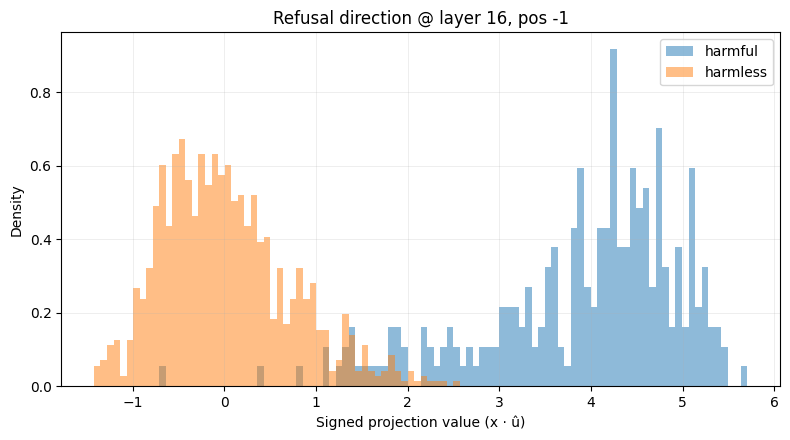

{'harmful': {'mean': 3.887638568878174, 'std': 1.1058862209320068, 'n': 260}, 'harmless': {'mean': 0.021758757531642914, 'std': 0.7013341784477234, 'n': 1000}, 'cohen_d(harmful_vs_harmless)': 4.823339843188406, 'AUROC(harmful>harmless)': 0.9924, 'mean_gap(harmful - harmless)': 3.865879774093628}


In [215]:
#llama 3.1 8b base
lb_meta, lb_dir = load_refusal("Meta-Llama-3.1-8B")

lb_proj_hf, lb_proj_hl, stats = project_along_direction(lb_hf_stack, lb_hl_stack, layer_idx = lb_meta[1], pos_idx = lb_meta[0], w=lb_dir, sign_align=True)

plot_projection_densities(lb_proj_hf, lb_proj_hl, title=f"Refusal direction @ layer {lb_meta[1]}, pos {lb_meta[0]}")
print(stats)

/tmp/ipykernel_3118179/1315381035.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  refusal_dir = torch.load(prefix+"/direction.pt", map_location=torch.device('cpu'))


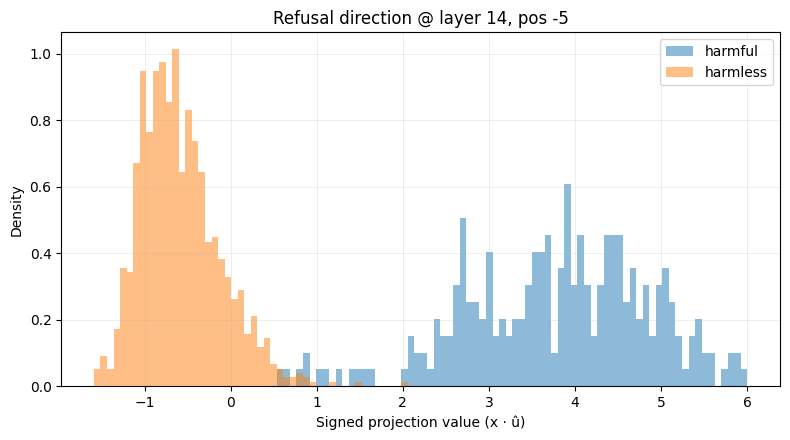

{'harmful': {'mean': 3.7858572006225586, 'std': 1.0871838331222534, 'n': 260}, 'harmless': {'mean': -0.5859050154685974, 'std': 0.4634051024913788, 'n': 1000}, 'cohen_d(harmful_vs_harmless)': 6.795477764307549, 'AUROC(harmful>harmless)': 0.9997846153846154, 'mean_gap(harmful - harmless)': 4.371762275695801}


In [34]:
# llama 3.1 8b instruct
li_meta, li_dir = load_refusal("Meta-Llama-3.1-8B-Instruct")

li_proj_hf, li_proj_hl, stats = project_along_direction(li_hf_stack, li_hl_stack, layer_idx = li_meta[1], pos_idx = li_meta[0], w=li_dir, sign_align=True)

plot_projection_densities(li_proj_hf, li_proj_hl, title=f"Refusal direction @ layer {li_meta[1]}, pos {li_meta[0]}")
print(stats)

/tmp/ipykernel_3118179/1315381035.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  refusal_dir = torch.load(prefix+"/direction.pt", map_location=torch.device('cpu'))


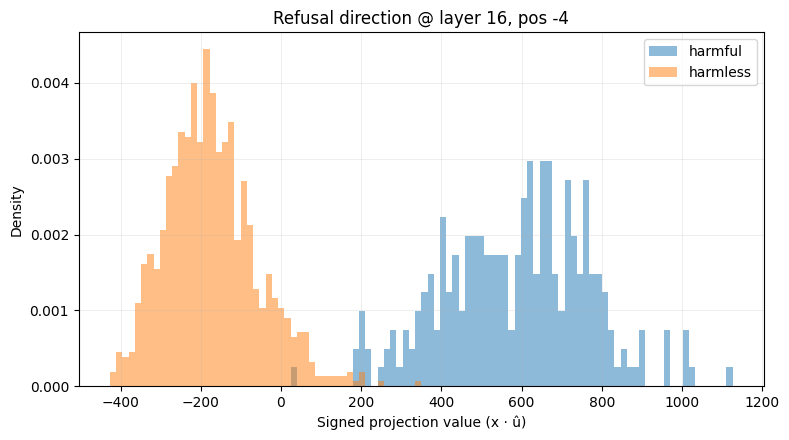

{'harmful': {'mean': 586.2008056640625, 'std': 181.521728515625, 'n': 260}, 'harmless': {'mean': -172.82923889160156, 'std': 113.6620101928711, 'n': 1000}, 'cohen_d(harmful_vs_harmless)': 5.81412894042243, 'AUROC(harmful>harmless)': 0.9996538461538461, 'mean_gap(harmful - harmless)': 759.030029296875}


In [37]:
# gpt oss 20b
oss_meta, oss_dir = load_refusal("gpt-oss-20b")

oss_proj_hf, oss_proj_hl, stats = project_along_direction(oss_hf_stack, oss_hl_stack, layer_idx = oss_meta[1], pos_idx = oss_meta[0], w=oss_dir, sign_align=True)

plot_projection_densities(oss_proj_hf, oss_proj_hl, title=f"Refusal direction @ layer {oss_meta[1]}, pos {oss_meta[0]}")
print(stats)

/tmp/ipykernel_3118179/1315381035.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  refusal_dir = torch.load(prefix+"/direction.pt", map_location=torch.device('cpu'))


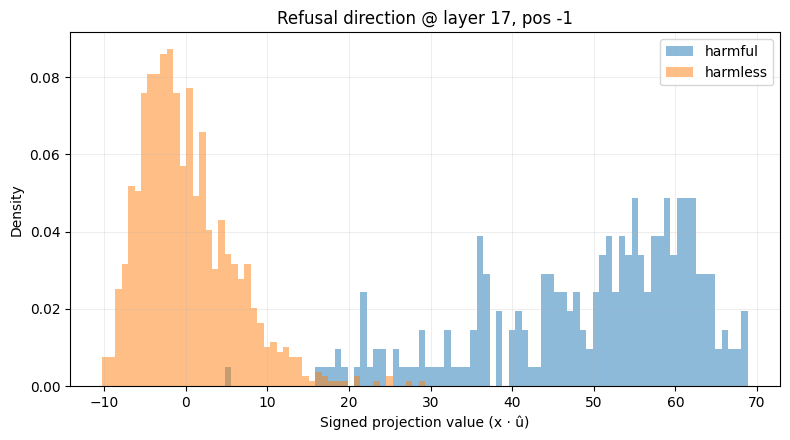

{'harmful': {'mean': 49.63025665283203, 'std': 12.921079635620117, 'n': 260}, 'harmless': {'mean': 0.0829029381275177, 'std': 5.7133331298828125, 'n': 1000}, 'cohen_d(harmful_vs_harmless)': 6.380885832993572, 'AUROC(harmful>harmless)': 0.9988307692307692, 'mean_gap(harmful - harmless)': 49.5473518371582}


In [241]:
# mixtral8x7b instruct
mix_meta, mix_dir = load_refusal("Mixtral-8x7B-Instruct-v0.1")

mix_proj_hf, mix_proj_hl, stats = project_along_direction(mix_hf_stack, mix_hl_stack, layer_idx = mix_meta[1], pos_idx = mix_meta[0], w=mix_dir, sign_align=True)

plot_projection_densities(mix_proj_hf, mix_proj_hl, title=f"Refusal direction @ layer {mix_meta[1]}, pos {mix_meta[0]}")
print(stats)

## visualize all layers and tokens

In [278]:
import matplotlib.pyplot as plt
import seaborn as sns

def compare_all_projections(mean_diff_loc, hf_stack, hl_stack):
    mean_diffs = mean_diff = torch.load(mean_diff_loc,
                          map_location=torch.device('cpu'))
    stat_dict = dict()    
    for n_pos, pos in enumerate(mean_diff):
        pos_dict = dict()
        
        #create ridge plot over all layers for each token position
        fig, axes = plt.subplots(len(pos), 1, figsize = (6,20), sharex=True)
        plt.suptitle(f"Token Position {n_pos-5}")
        plt.xlabel("Refusal Direction Projection")
        plt.tight_layout()
        sns.set(style="whitegrid")
        for n_layer, layer in enumerate(pos):
            proj_hf, proj_hl, stats = project_along_direction(hf_stack, hl_stack, layer_idx = n_layer, pos_idx = n_pos, w=layer, sign_align=True)

            sns.kdeplot(proj_hf, ax = axes[n_layer], fill = True, color = "red", label = "harmful", linewidth=1.5)
            sns.kdeplot(proj_hl, ax = axes[n_layer], fill = True, color = "blue", label = "harmless", linewidth=1.5)
            
            axes[n_layer].set_ylabel("")
            axes[n_layer].set_yticks([])
            axes[n_layer].set_title(n_layer)

            pos_dict[f"layer{n_layer}"]={"cohen_d":cohen_d(proj_hf, proj_hl),
                                    "auc": auc_from_scores(proj_hf, proj_hl),
                                    "mean_gap": float(proj_hf.mean() - proj_hl.mean())}
            
        plt.show()
        stat_dict[f"pos{n_pos}"] = pos_dict

    return stat_dict



In [286]:
def compare_layer_selection(stat_dict, arditi_meta, model_name):
    best = {}

    for pos, layers in stat_dict.items():
        for lay, metrics in layers.items():
            for metric, value in metrics.items():
                if metric not in best or value > best[metric]["value"]:
                    best[metric] = {"pos": pos, "layer": lay, "value": value}
    
    # Display results
    print(f"{model_name} best layer/pos:")
    for metric, info in best.items():
        print(f"{metric}: layer={info['layer']}, pos={info['pos']}, value={info['value']:.3f}")
    
    print(f"Arditi: layer={arditi_meta[1]}, pos={arditi_meta[0]}")

## compare all layers results

#### llama base

/tmp/ipykernel_3118179/3480101473.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mean_diffs = mean_diff = torch.load(mean_diff_loc,


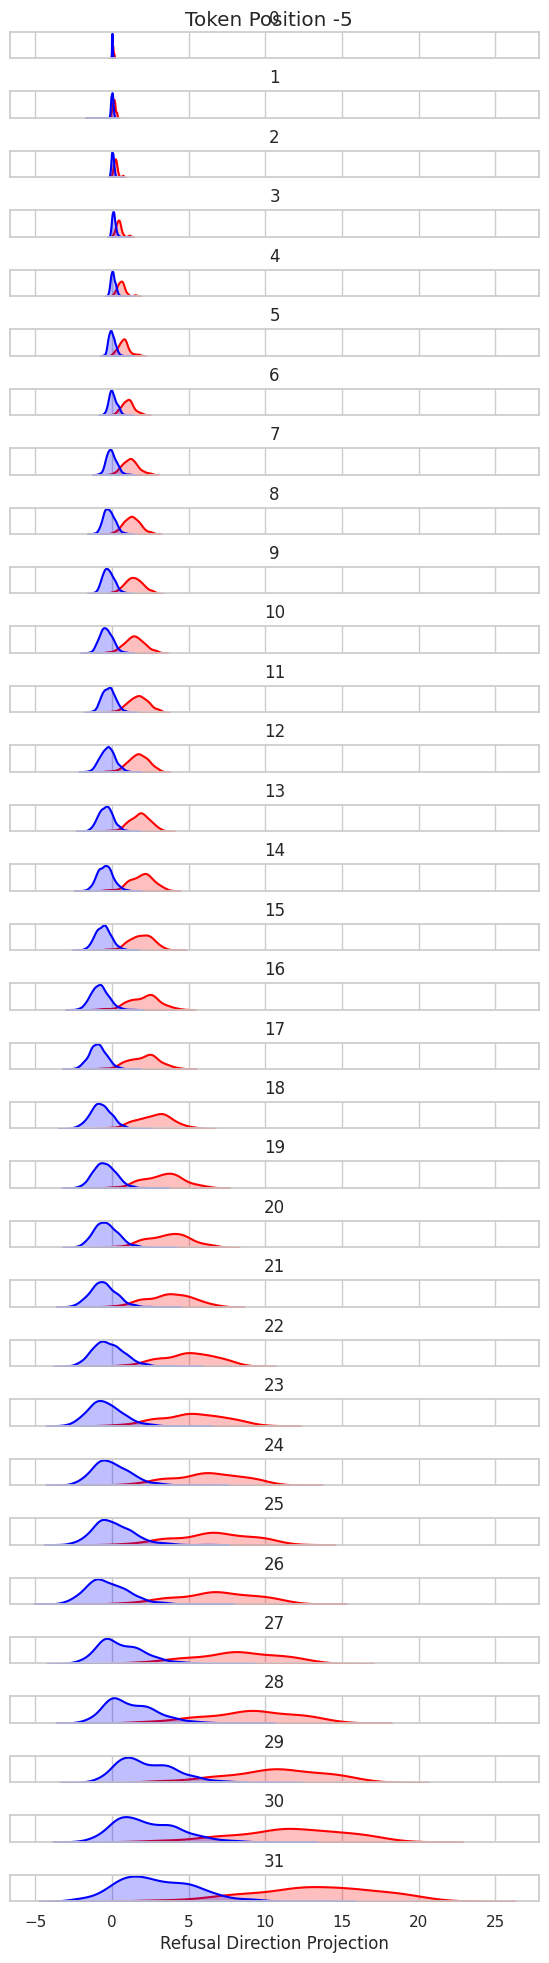

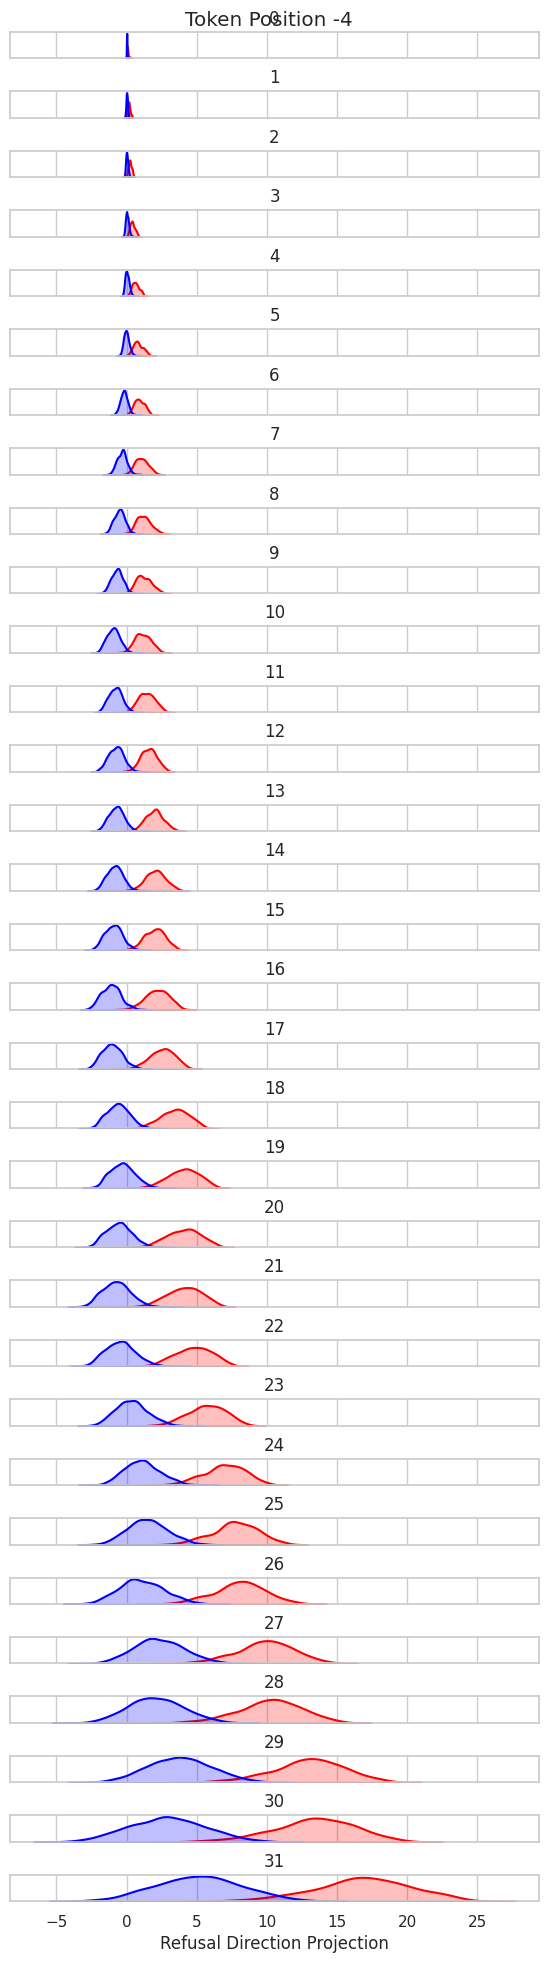

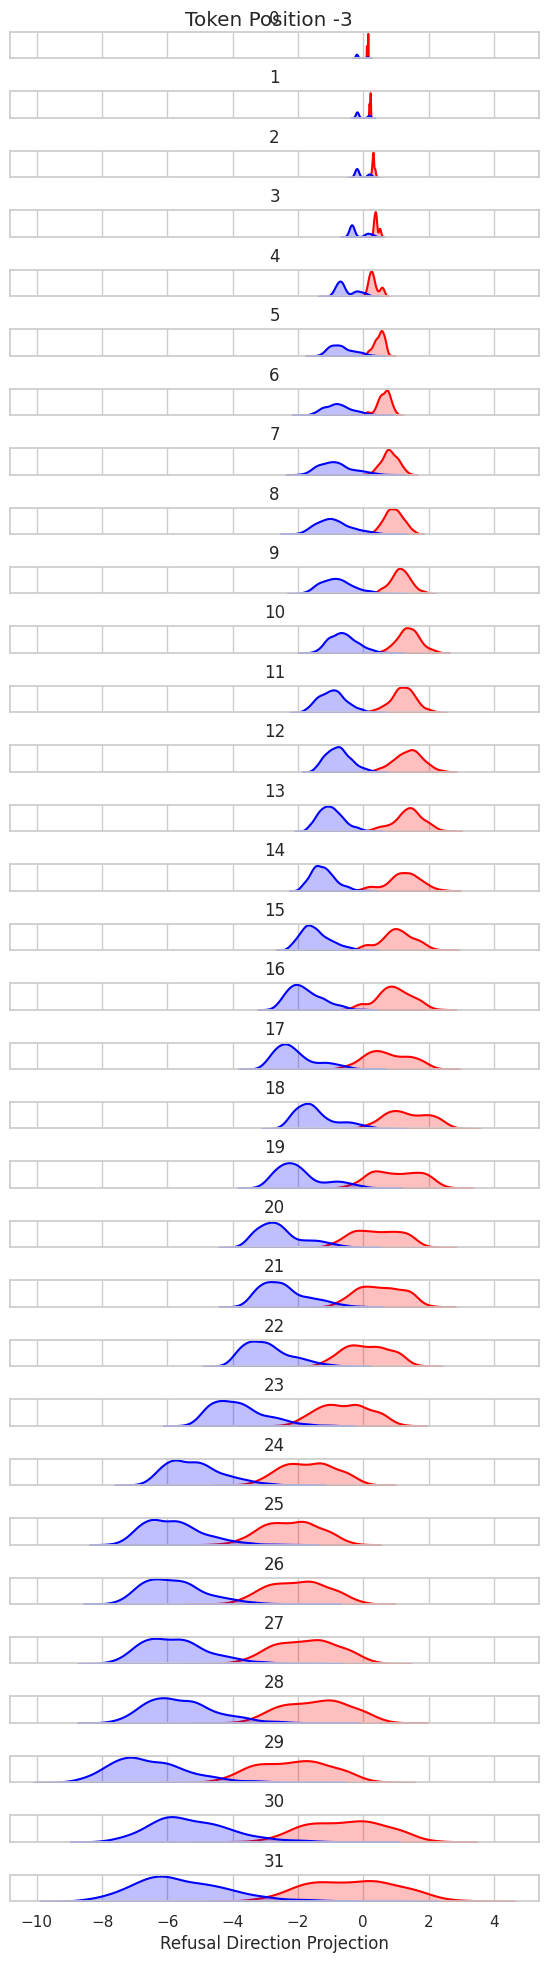

/tmp/ipykernel_3118179/3480101473.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hf, ax = axes[n_layer], fill = True, color = "red", label = "harmful", linewidth=1.5)
/tmp/ipykernel_3118179/3480101473.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hl, ax = axes[n_layer], fill = True, color = "blue", label = "harmless", linewidth=1.5)


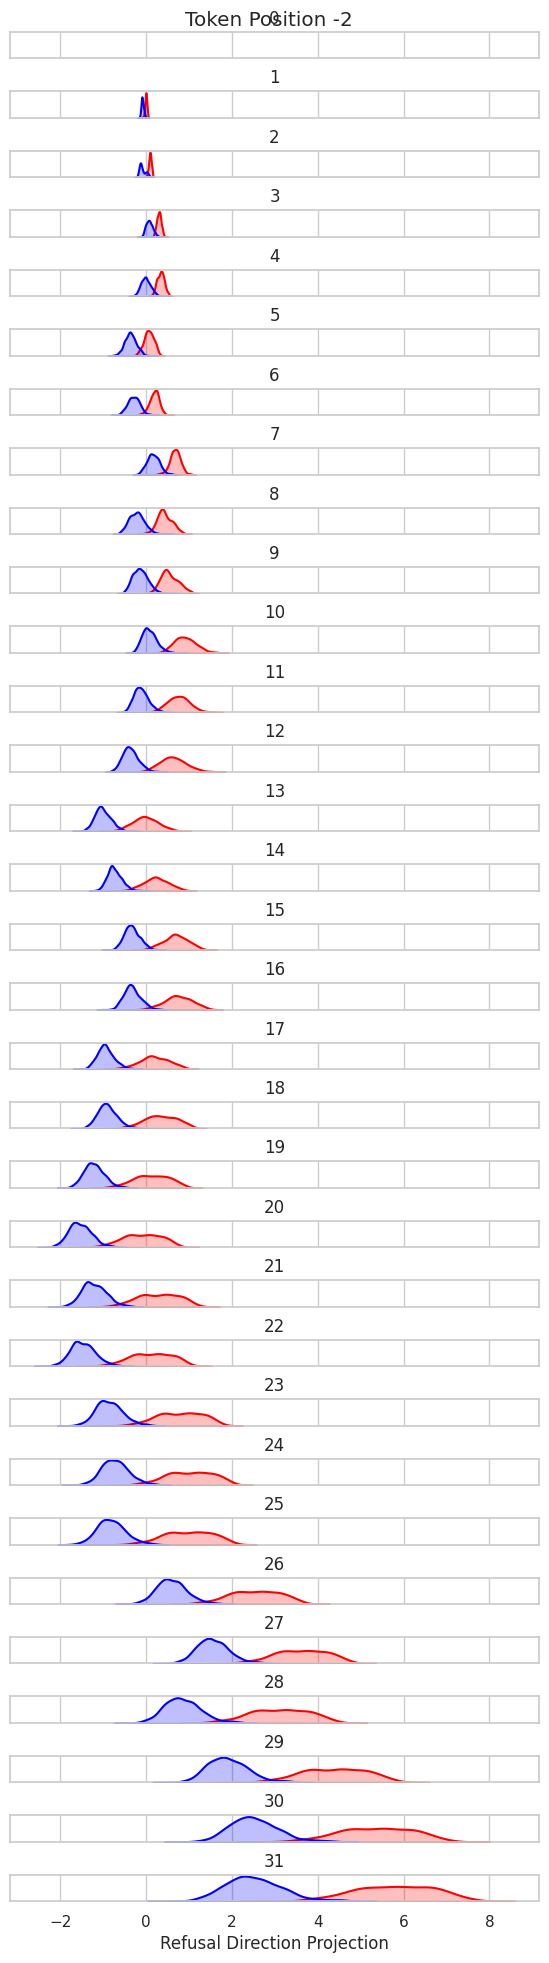

/tmp/ipykernel_3118179/3480101473.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hf, ax = axes[n_layer], fill = True, color = "red", label = "harmful", linewidth=1.5)
/tmp/ipykernel_3118179/3480101473.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hl, ax = axes[n_layer], fill = True, color = "blue", label = "harmless", linewidth=1.5)


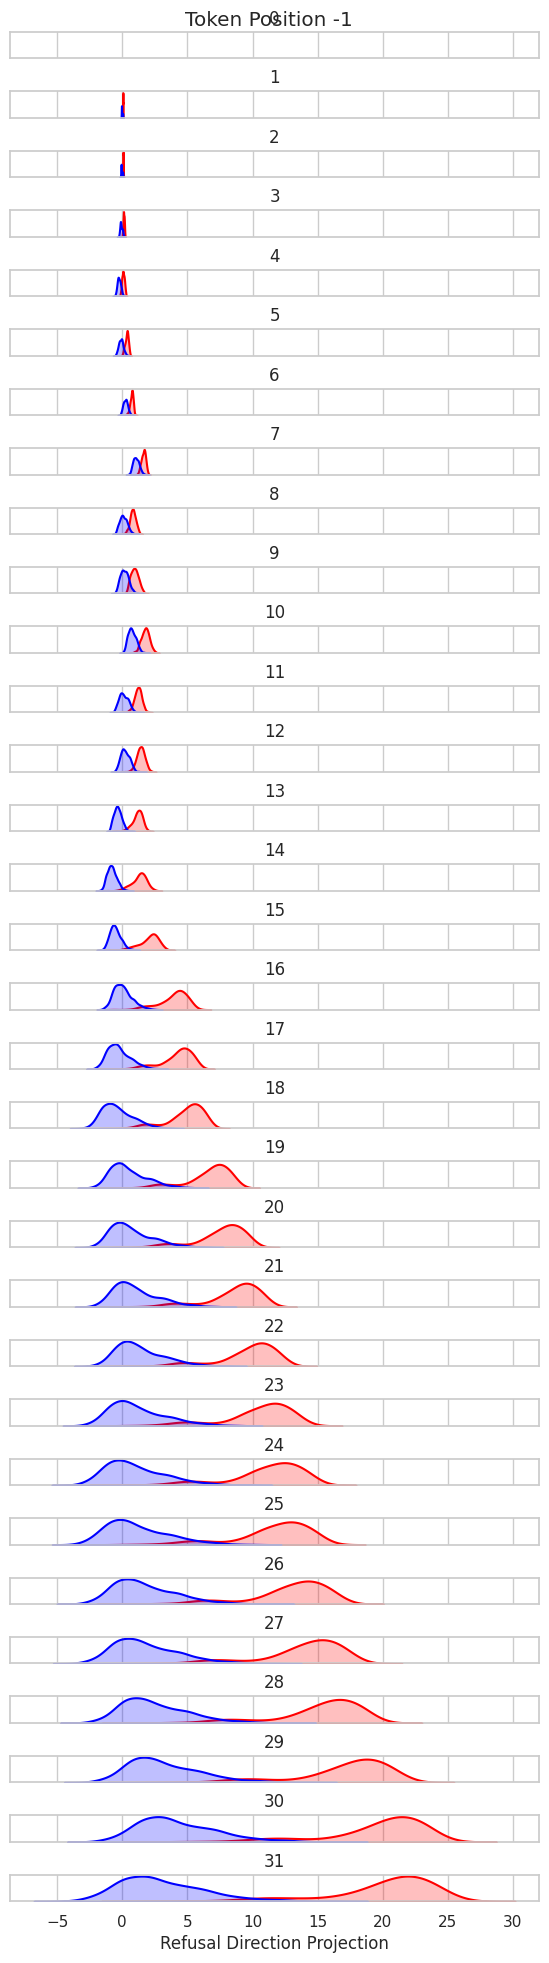

In [279]:
lb_stat_dict = compare_all_projections("/media/anna/Samsung_T5/alignment/runs/Meta-Llama-3.1-8B/generate_directions/mean_diffs.pt",
                        lb_hf_stack,
                        lb_hl_stack)

In [285]:
compare_layer_selection(lb_stat_dict, lb_meta, "Llama 3.1 8b Base")

Llama 3.1 8b Base best layer/pos:
cohen_d: layer=layer14, pos=pos2, value=6.188
auc: layer=layer13, pos=pos2, value=1.000
mean_gap: layer=layer31, pos=pos4, value=16.954
Arditi layer=16, pos=-1


#### llama instruct

/tmp/ipykernel_3118179/3480101473.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mean_diffs = mean_diff = torch.load(mean_diff_loc,
/tmp/ipykernel_3118179/3480101473.py

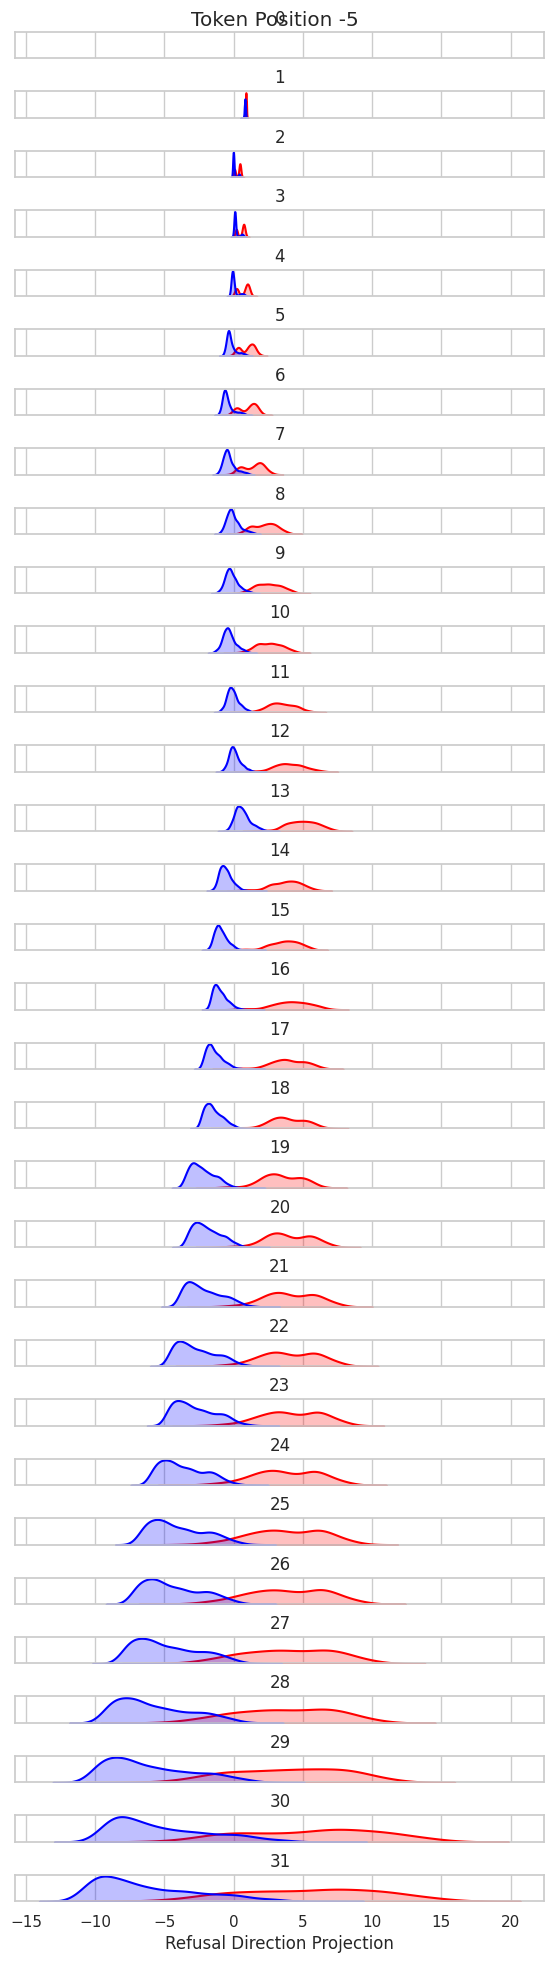

/tmp/ipykernel_3118179/3480101473.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hf, ax = axes[n_layer], fill = True, color = "red", label = "harmful", linewidth=1.5)
/tmp/ipykernel_3118179/3480101473.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hl, ax = axes[n_layer], fill = True, color = "blue", label = "harmless", linewidth=1.5)


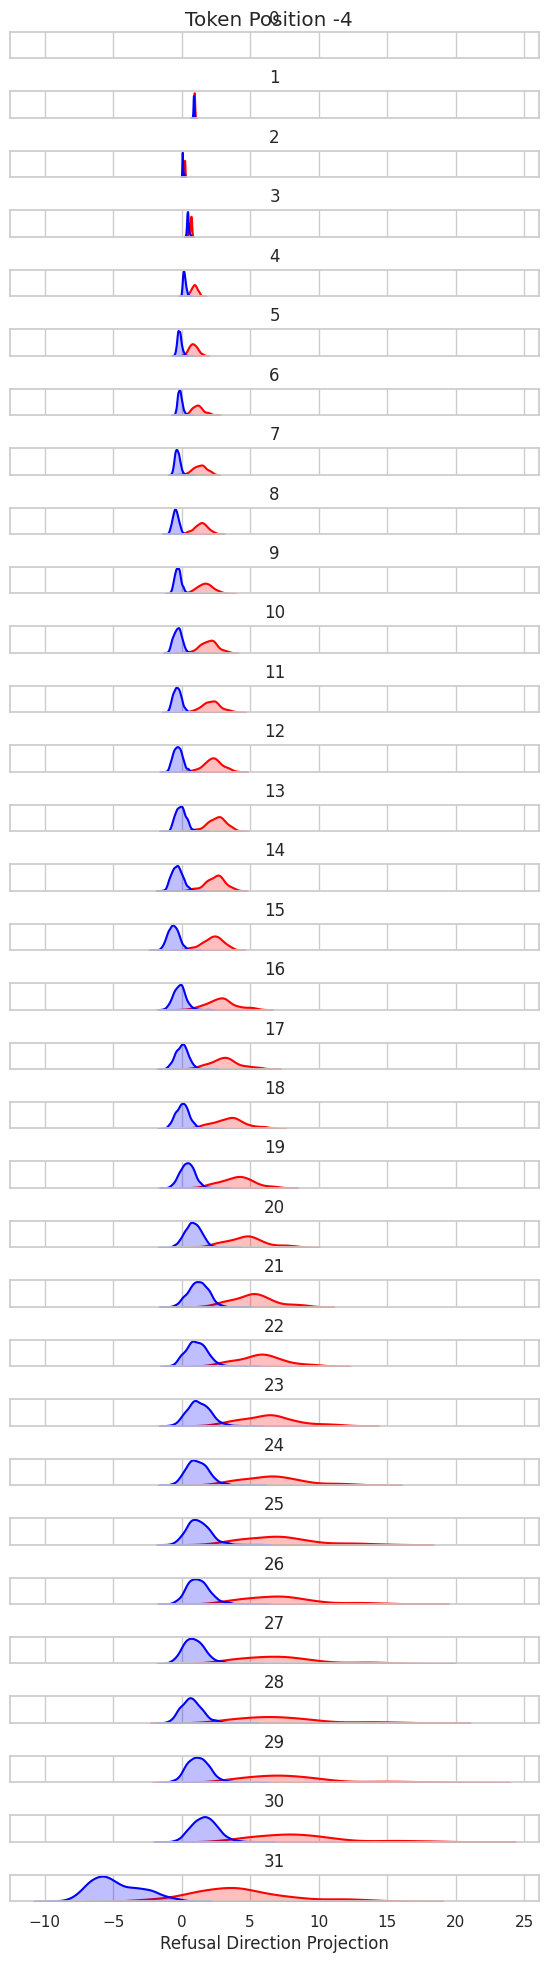

/tmp/ipykernel_3118179/3480101473.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hf, ax = axes[n_layer], fill = True, color = "red", label = "harmful", linewidth=1.5)
/tmp/ipykernel_3118179/3480101473.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hl, ax = axes[n_layer], fill = True, color = "blue", label = "harmless", linewidth=1.5)


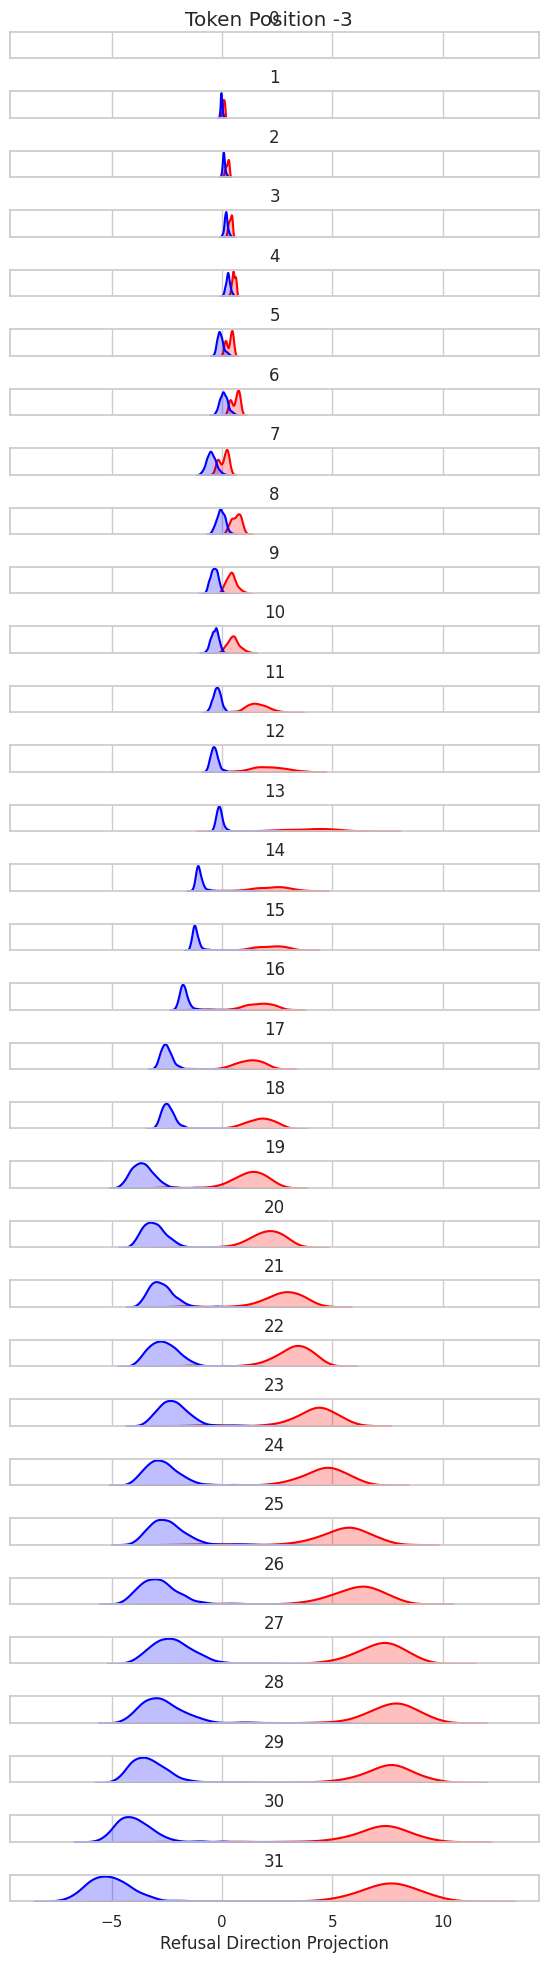

/tmp/ipykernel_3118179/3480101473.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hf, ax = axes[n_layer], fill = True, color = "red", label = "harmful", linewidth=1.5)
/tmp/ipykernel_3118179/3480101473.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hl, ax = axes[n_layer], fill = True, color = "blue", label = "harmless", linewidth=1.5)


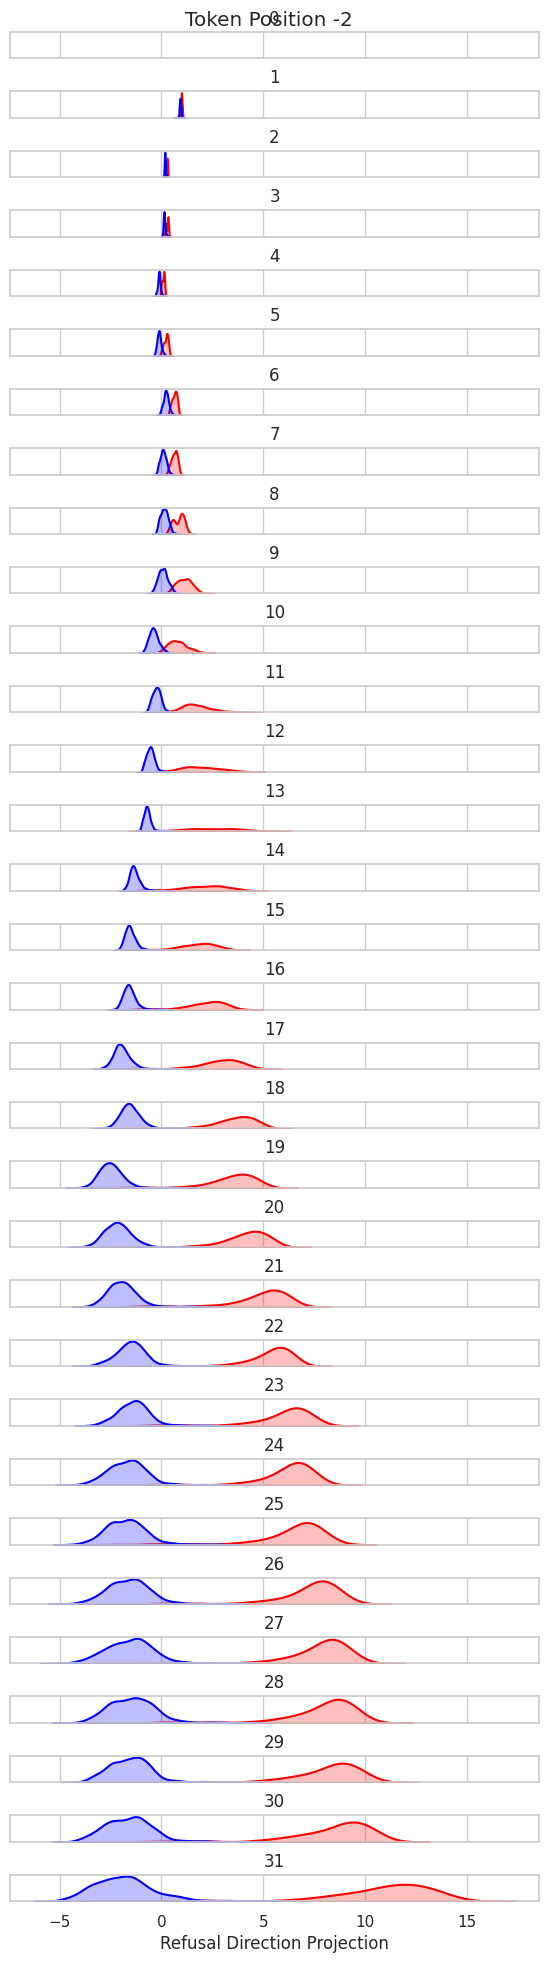

/tmp/ipykernel_3118179/3480101473.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hf, ax = axes[n_layer], fill = True, color = "red", label = "harmful", linewidth=1.5)
/tmp/ipykernel_3118179/3480101473.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hl, ax = axes[n_layer], fill = True, color = "blue", label = "harmless", linewidth=1.5)


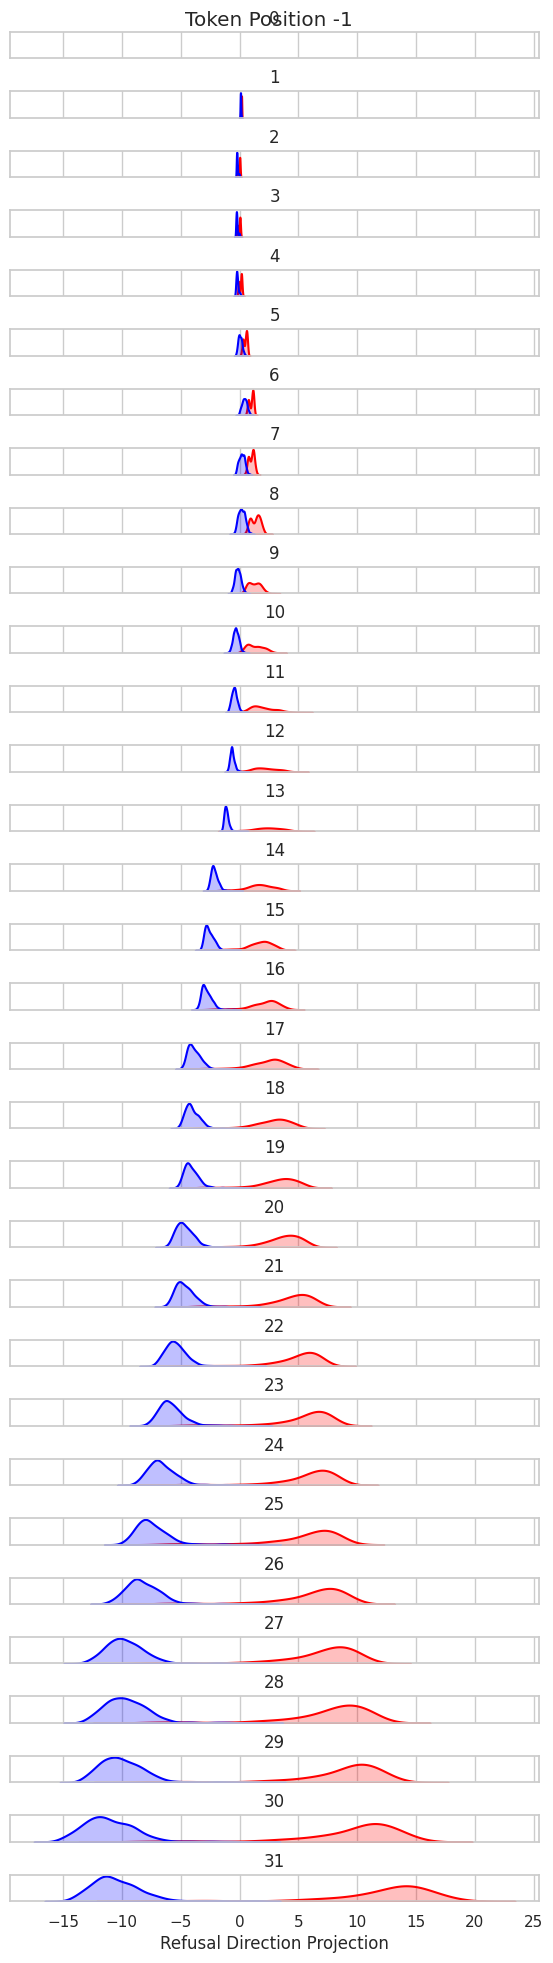

In [288]:
li_stat_dict = compare_all_projections("/media/anna/Samsung_T5/alignment/runs/Meta-Llama-3.1-8B-Instruct/generate_directions/mean_diffs.pt",
                        li_hf_stack,
                        li_hl_stack)

In [289]:
compare_layer_selection(li_stat_dict, li_meta, "Llama 3.1 8b Instruct")

Llama 3.1 8b Instruct best layer/pos:
cohen_d: layer=layer0, pos=pos0, value=nan
auc: layer=layer14, pos=pos0, value=1.000
mean_gap: layer=layer31, pos=pos4, value=22.448
Arditi: layer=14, pos=-5


#### oss

/tmp/ipykernel_3118179/3480101473.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mean_diffs = mean_diff = torch.load(mean_diff_loc,


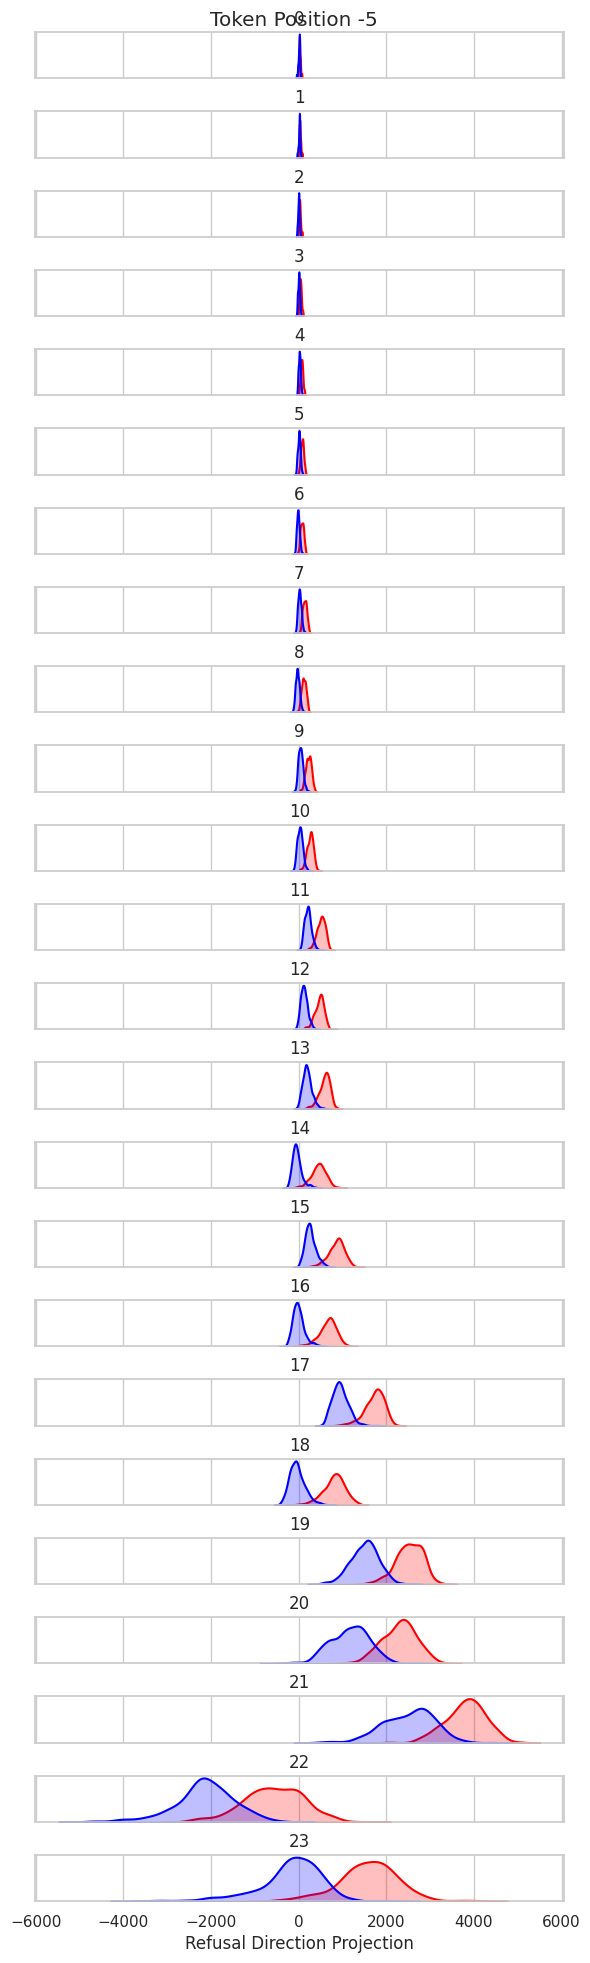

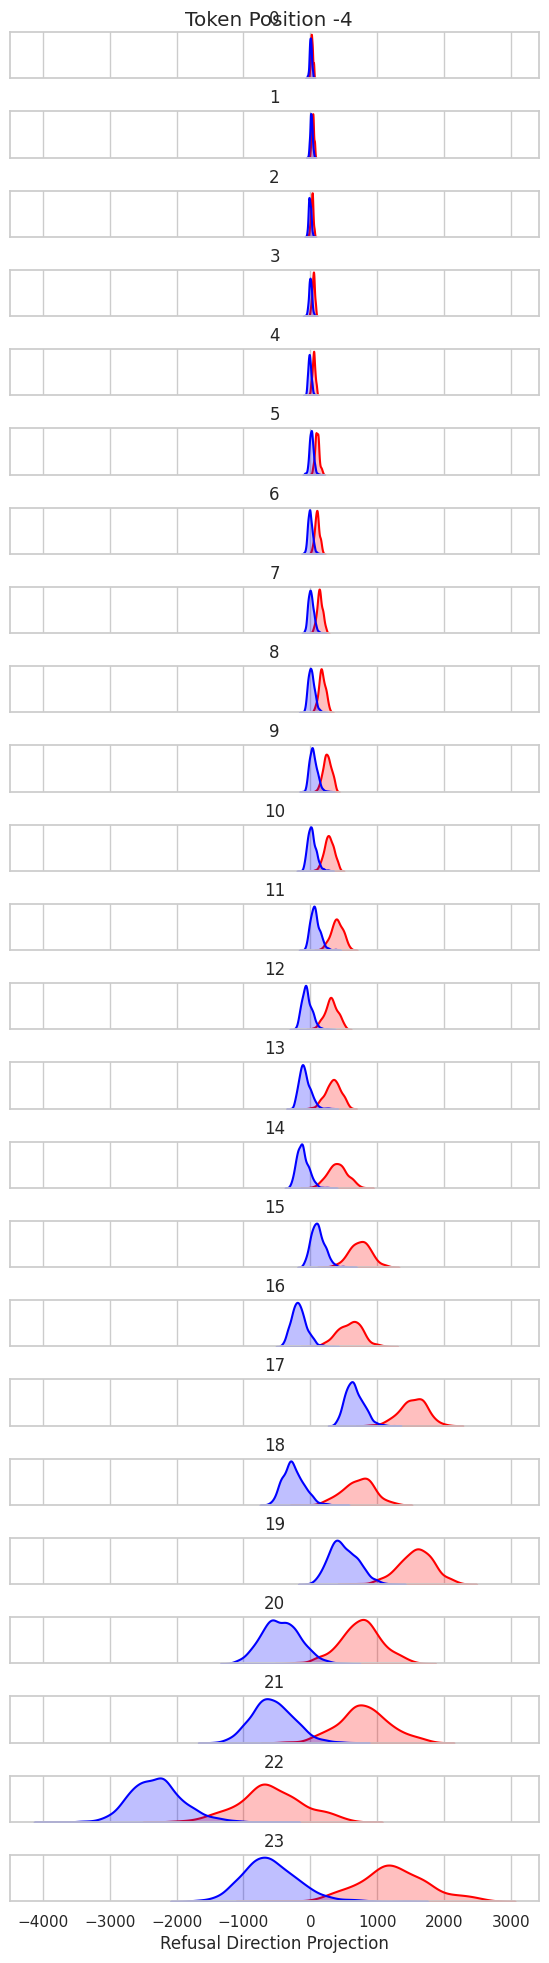

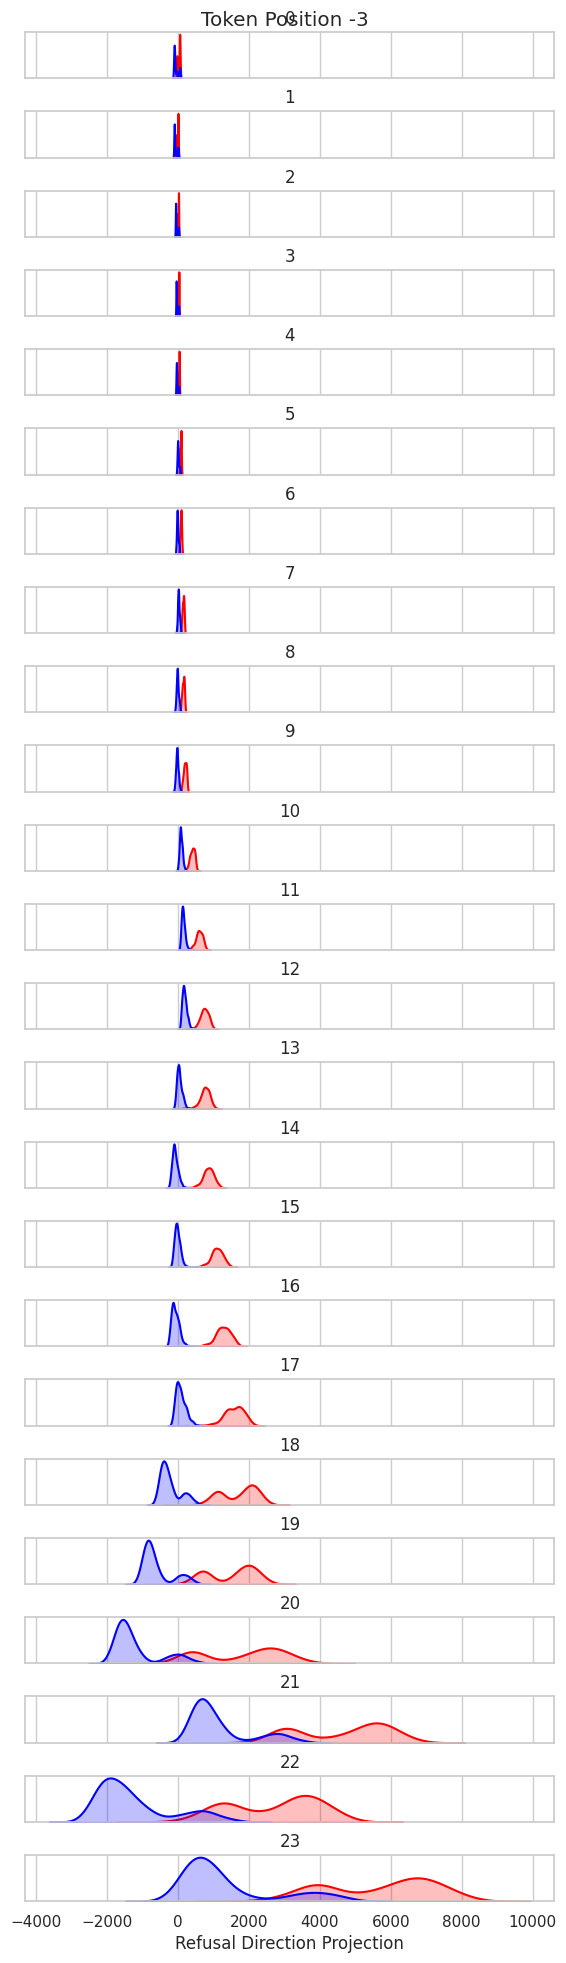

/tmp/ipykernel_3118179/3480101473.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hf, ax = axes[n_layer], fill = True, color = "red", label = "harmful", linewidth=1.5)
/tmp/ipykernel_3118179/3480101473.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hl, ax = axes[n_layer], fill = True, color = "blue", label = "harmless", linewidth=1.5)


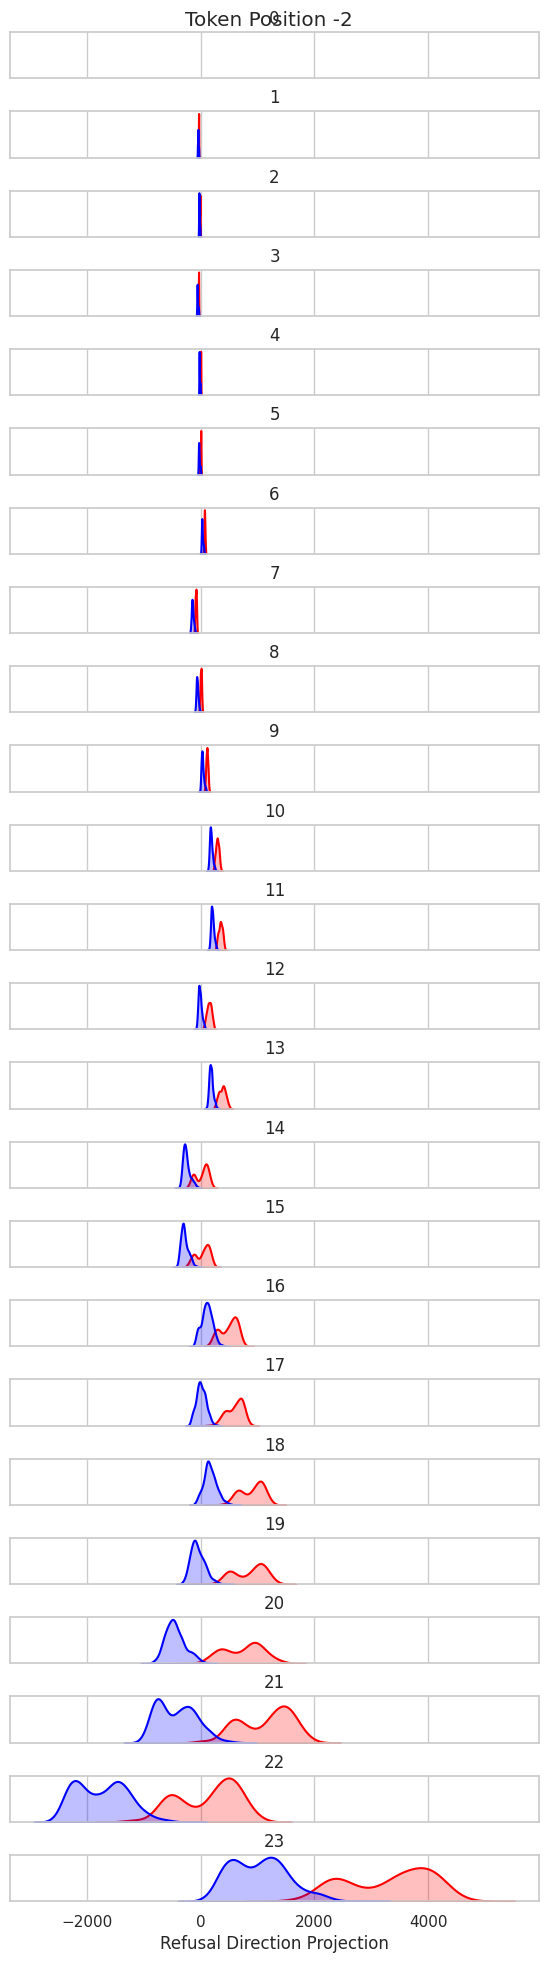

/tmp/ipykernel_3118179/3480101473.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hf, ax = axes[n_layer], fill = True, color = "red", label = "harmful", linewidth=1.5)
/tmp/ipykernel_3118179/3480101473.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hl, ax = axes[n_layer], fill = True, color = "blue", label = "harmless", linewidth=1.5)


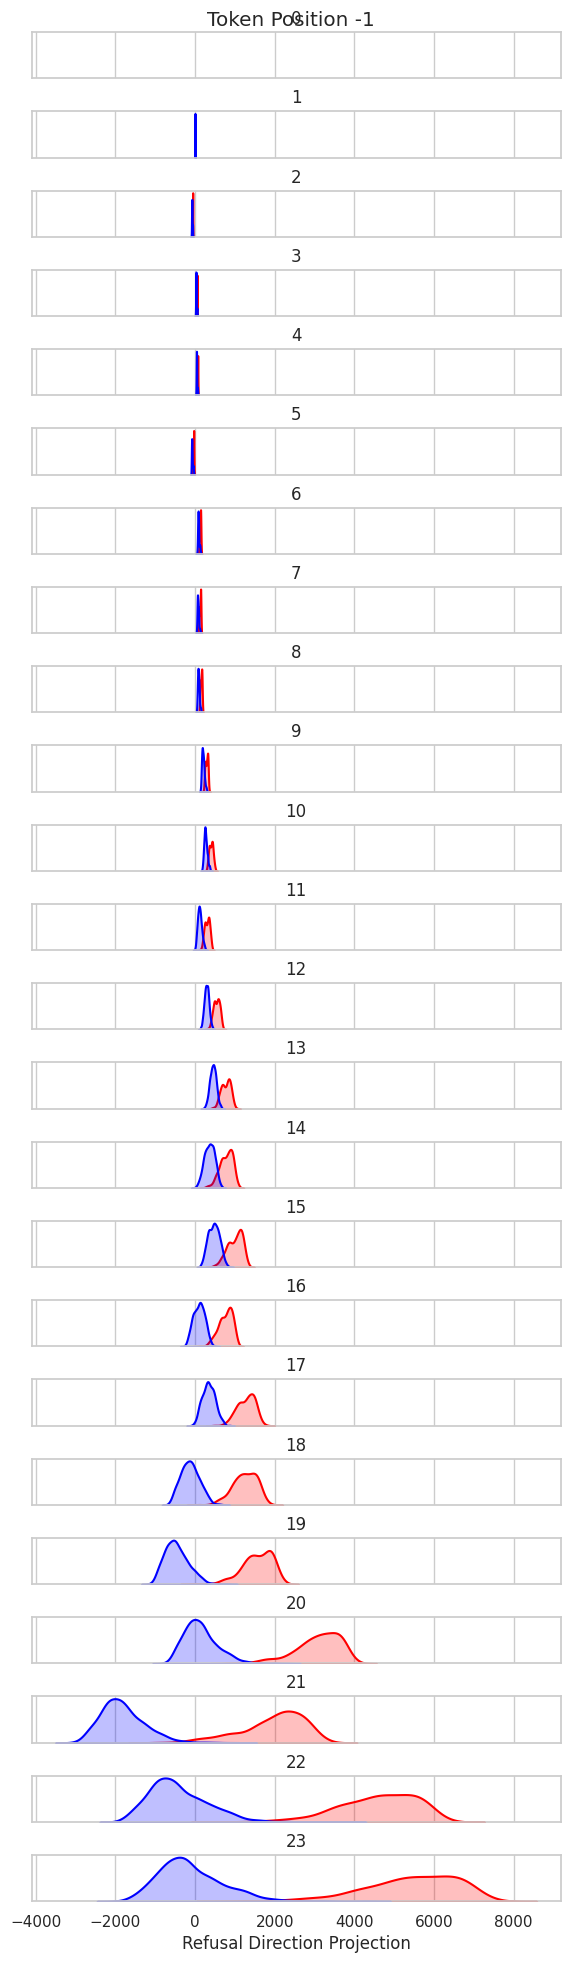

In [290]:
oss_stat_dict = compare_all_projections("/media/anna/Samsung_T5/alignment/runs/gpt-oss-20b/generate_directions/mean_diffs.pt",
                        oss_hf_stack,
                        oss_hl_stack)

In [291]:
compare_layer_selection(oss_stat_dict, oss_meta, "GPT OSS 20b")

GPT OSS 20b best layer/pos:
cohen_d: layer=layer16, pos=pos2, value=8.968
auc: layer=layer9, pos=pos2, value=1.000
mean_gap: layer=layer23, pos=pos4, value=5539.357
Arditi: layer=16, pos=-4


#### mixtral8x7B

/tmp/ipykernel_3118179/3480101473.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mean_diffs = mean_diff = torch.load(mean_diff_loc,


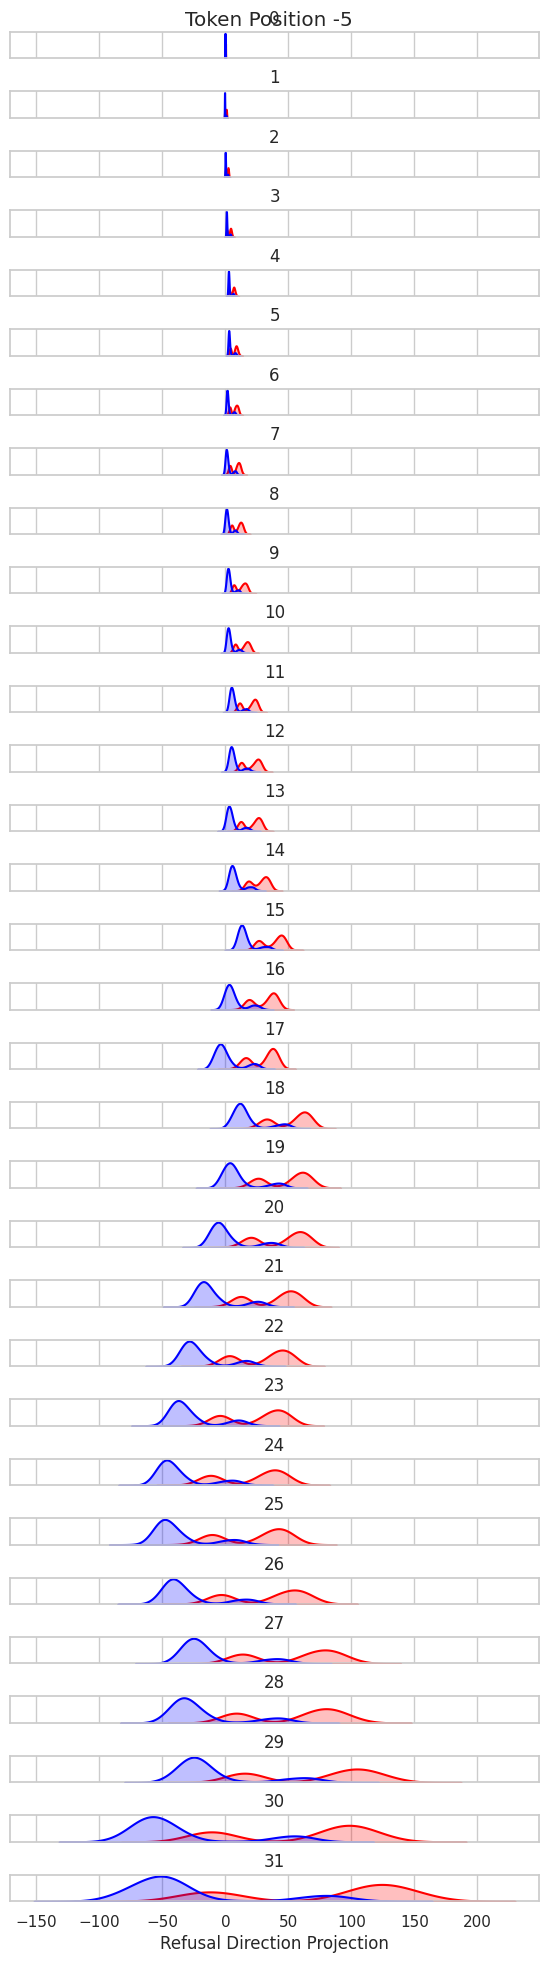

/tmp/ipykernel_3118179/3480101473.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hf, ax = axes[n_layer], fill = True, color = "red", label = "harmful", linewidth=1.5)
/tmp/ipykernel_3118179/3480101473.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hl, ax = axes[n_layer], fill = True, color = "blue", label = "harmless", linewidth=1.5)


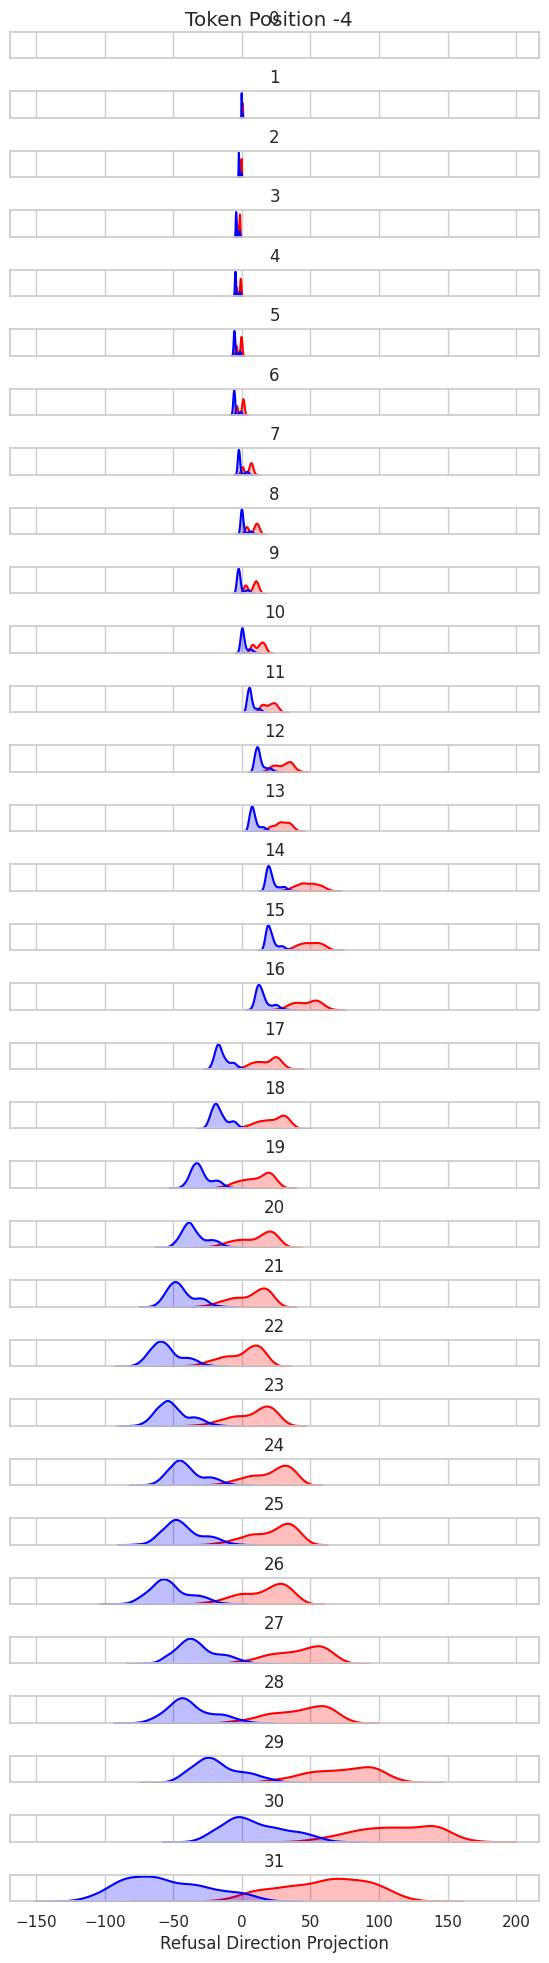

/tmp/ipykernel_3118179/3480101473.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hf, ax = axes[n_layer], fill = True, color = "red", label = "harmful", linewidth=1.5)
/tmp/ipykernel_3118179/3480101473.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hl, ax = axes[n_layer], fill = True, color = "blue", label = "harmless", linewidth=1.5)


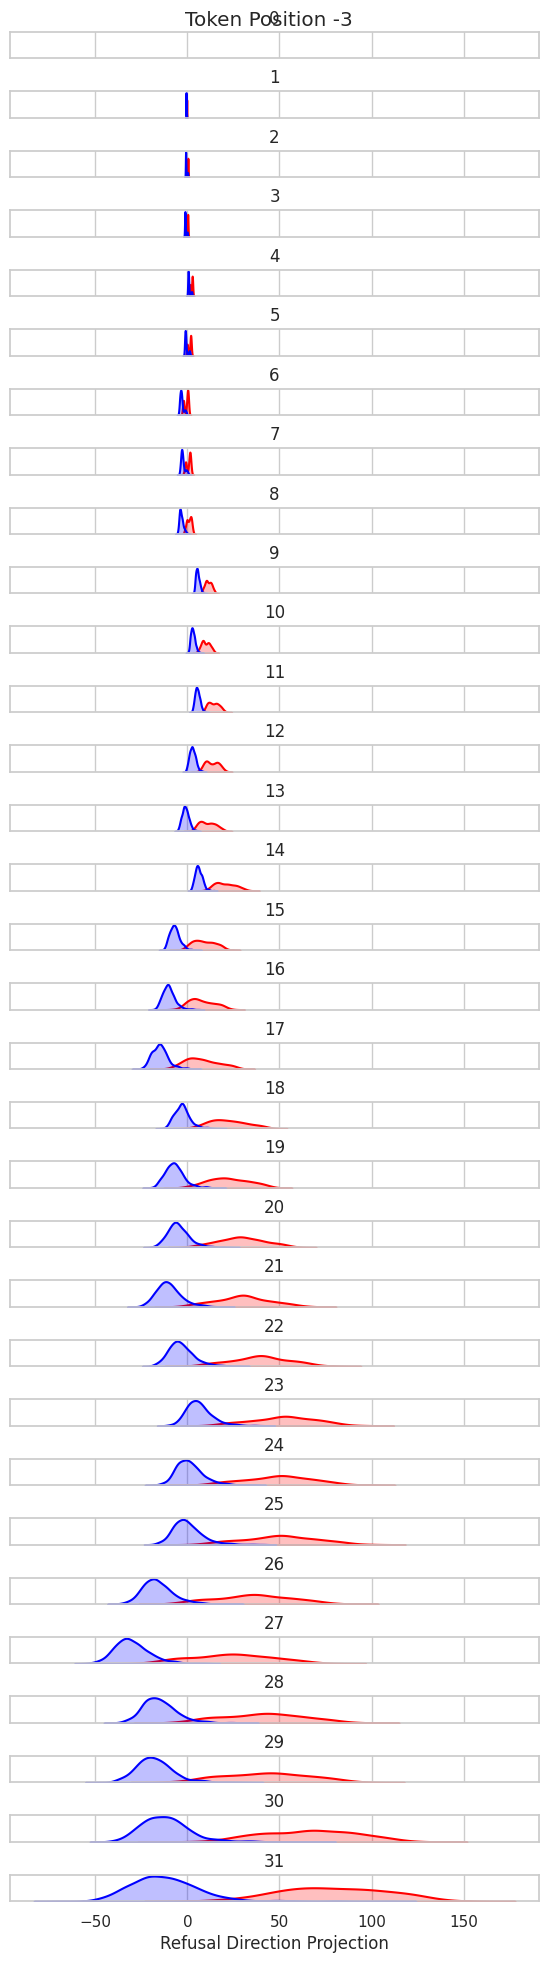

/tmp/ipykernel_3118179/3480101473.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hf, ax = axes[n_layer], fill = True, color = "red", label = "harmful", linewidth=1.5)
/tmp/ipykernel_3118179/3480101473.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hl, ax = axes[n_layer], fill = True, color = "blue", label = "harmless", linewidth=1.5)


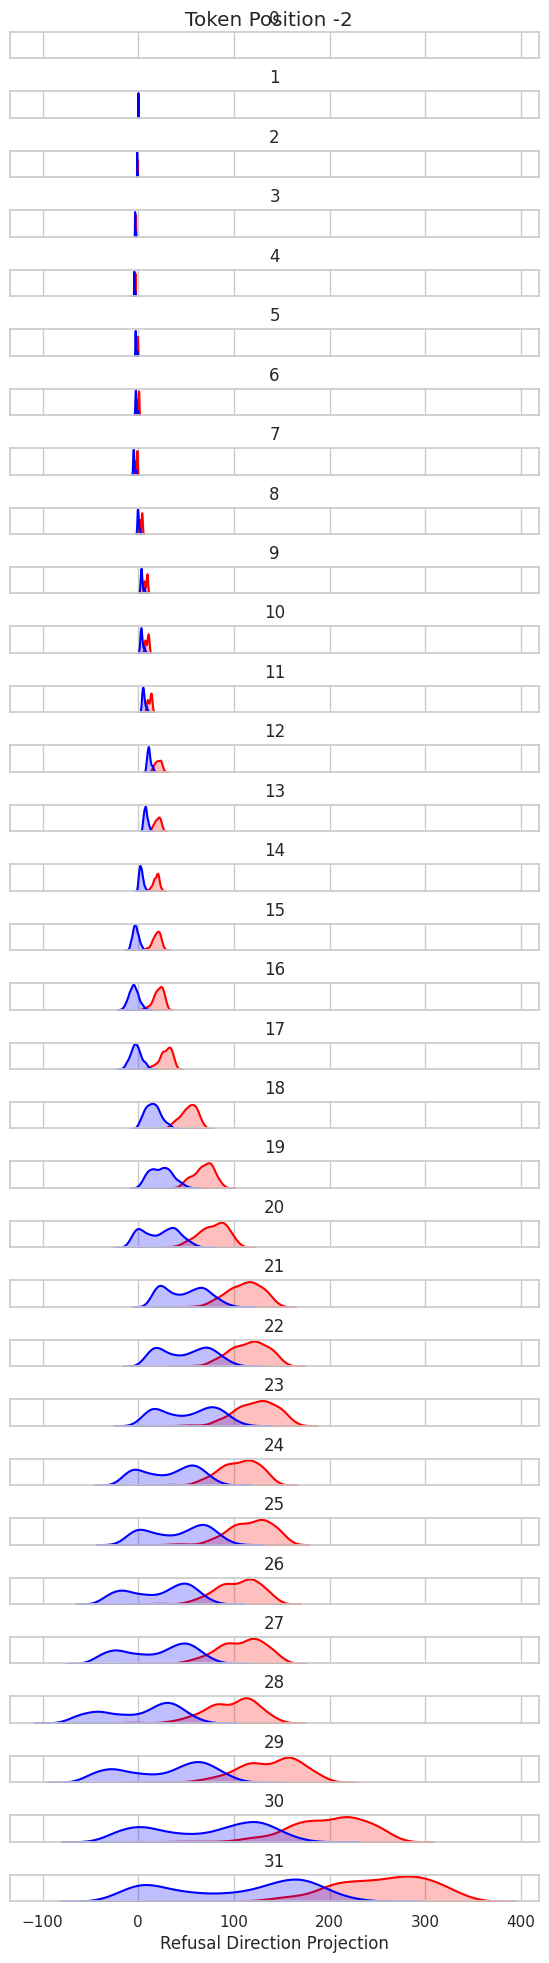

/tmp/ipykernel_3118179/3480101473.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hf, ax = axes[n_layer], fill = True, color = "red", label = "harmful", linewidth=1.5)
/tmp/ipykernel_3118179/3480101473.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(proj_hl, ax = axes[n_layer], fill = True, color = "blue", label = "harmless", linewidth=1.5)


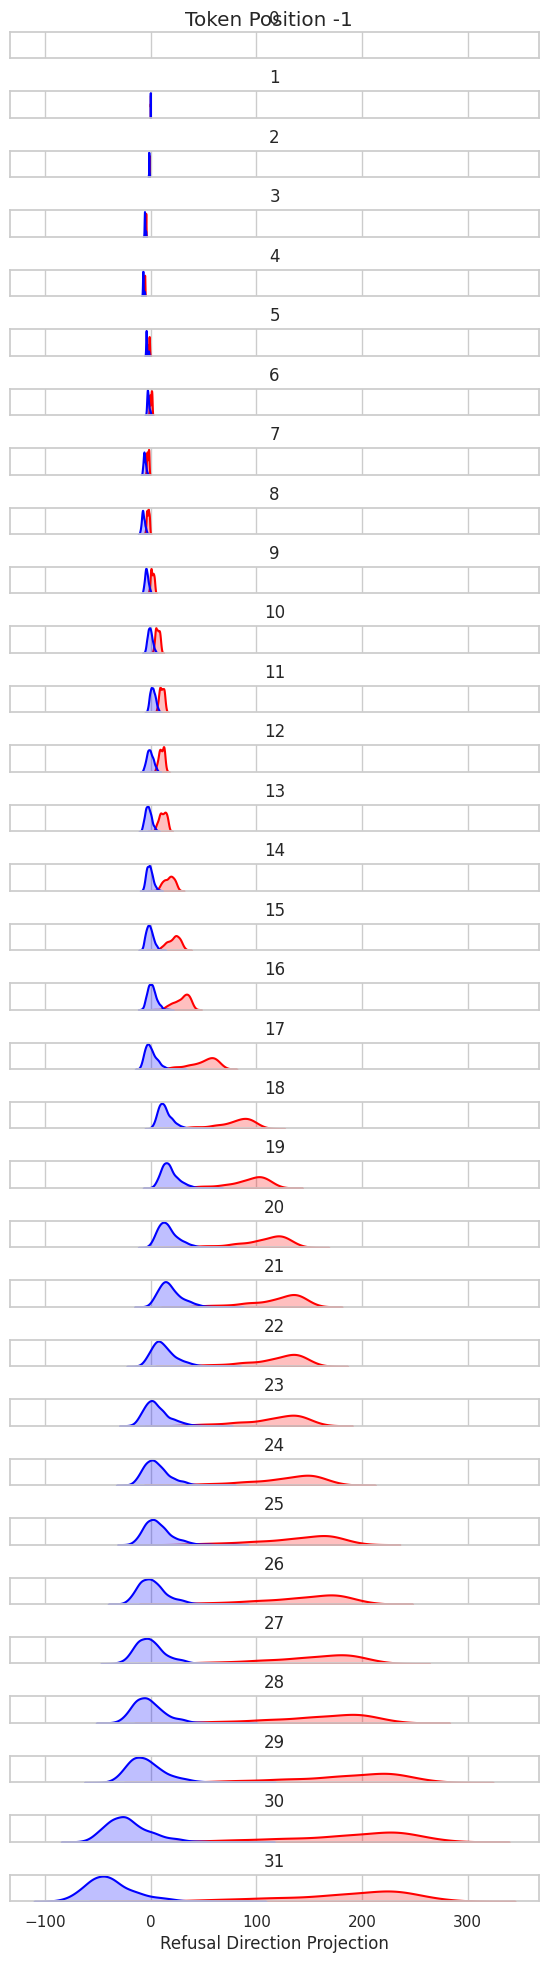

In [292]:
mix_stat_dict = compare_all_projections("/media/anna/Samsung_T5/alignment/runs/Mixtral-8x7B-Instruct-v0.1/generate_directions/mean_diffs.pt",
                        mix_hf_stack,
                        mix_hl_stack)

In [293]:
compare_layer_selection(mix_stat_dict, mix_meta, "Mixtral8x7B Instruct")

Mixtral8x7B Instruct best layer/pos:
cohen_d: layer=layer14, pos=pos3, value=6.908
auc: layer=layer14, pos=pos3, value=1.000
mean_gap: layer=layer31, pos=pos4, value=222.507
Arditi: layer=17, pos=-1


# Contrastive PCA

- Center and project harmful activations based on harmless activations mu and PCA
- Then compute PCA on the "whitened" harmful activations
- Alternative method to a traditional cPCA, but numerically stable and more efficient
  - Instead of subtracting two full covariance matrices:
    - Directions which hold a lot of the background variance are shrunk
    - Directions with little background variance are amplified
    - PCA reveals directions with large target variance and little background variance
 


## whitened implementation

In [119]:
@torch.no_grad()
def cpca_whitened(X_target, X_bg, eps=1e-6, keep_var=0.999, eig_floor_frac=1e-3, renorm_cols=True):
    X_target = X_target.to(torch.float64).cpu()
    X_bg     = X_bg.to(torch.float64).cpu()

    # 1) Background PCA
    Xb_c = X_bg - X_bg.mean(0, keepdim=True)
    U, S, Vt = torch.linalg.svd(Xb_c, full_matrices=False)   # [N_b,r], [r], [r,H]
    var_b_all = (S**2) / max(1, X_bg.shape[0]-1)             # [r]
    Vb_all = Vt.T                                            # [H, r]

    # 2) Truncate to keep 'keep_var' fraction of variance
    order = torch.argsort(var_b_all, descending=True)
    var_b_sorted = var_b_all[order]
    Vb_sorted = Vb_all[:, order]
    cum = torch.cumsum(var_b_sorted, dim=0) / var_b_sorted.sum()
    r_keep = int(torch.searchsorted(cum, torch.tensor(keep_var), right=True).item()) + 1
    var_b = var_b_sorted[:r_keep].contiguous()
    Vb    = Vb_sorted[:, :r_keep].contiguous()

    # 3) Floor small eigenvalues before inverting
    tau = eig_floor_frac * var_b.mean()
    inv_sqrt = (var_b.clamp_min(tau) + eps).rsqrt()

    # 4) Whitening
    mu_b = X_bg.mean(0, keepdim=True)
    def whiten(X):
        Xc = X - mu_b
        return (Xc @ Vb) * inv_sqrt  # [N, r_keep]

    Zt = whiten(X_target)
    # (Optional) Zt = Zt - Zt.mean(0, keepdim=True)

    # 5) PCA on whitened target
    Uz, Sz, Vzt = torch.linalg.svd(Zt, full_matrices=False)
    lam = (Sz**2) / max(1, Zt.shape[0]-1)   # Rayleigh ratios
    Vz  = Vzt.T                             # [r_keep, r_z]

    # 6) Back-map + optional column renorm to unit bg variance
    C = (Vb * inv_sqrt.unsqueeze(0)) @ Vz   # [H, r_z]

    if renorm_cols:
        Xb0 = X_bg - mu_b
        # exact unit variance on harmless along every component
        s2 = (Xb0 @ C).var(dim=0, unbiased=True)  # [r_z]
        C = C / torch.sqrt(s2.clamp_min(1e-12))   # rescale columns

    lam_pos = lam.clamp_min(0)
    explained = lam_pos / lam_pos.sum().clamp_min(eps)

    return {"mu_b": mu_b.squeeze(0),
            "V_b": Vb, "var_b": var_b,
            "Vz": Vz, "lam": lam,
            "components": C,
            "explained": explained}


In [134]:
# iterate through layers and token positions, choose "best" PCA based on contrastive variance concentration

@torch.no_grad()
def get_lp_slices(X_h_lpnh, X_s_lpnh, layer, pos):
    Xt = X_h_lpnh[layer, pos].to(torch.float64, non_blocking=True).cpu()
    Xb = X_s_lpnh[layer, pos].to(torch.float64, non_blocking=True).cpu()
    return Xt, Xb

def contrastive_concentration_score(lam: torch.Tensor, k: int = 1) -> float:
    # fraction of positive contrastive variance captured by first k cPCs
    lam_pos = lam.clamp(min=0)
    s = lam_pos.sum()
    return float(lam_pos[:k].sum() / (s if s > 0 else 1.0))

def rayleigh_from_whitened(lam):
    # lam is from PCA on Zt; equals Rayleigh ratios.
    return float(lam[0].item())

@torch.no_grad()
def mean_gap_on_component(c, Xt, Xb, mu_b):
    # project *centered-by-mu_b* data onto the back-mapped component
    zt = (Xt - mu_b) @ c
    zb = (Xb - mu_b) @ c
    gap = (zt.mean() - zb.mean()).abs().item()
    denom = (zb.var(unbiased=True).sqrt().item() + 1e-12)  # background scale
    return gap / denom

def alt_score_white(res, Xt, Xb):
    v1_z   = res["Vz"][:, 0]                 # whitened-space PC1
    c1     = res["components"][:, 0]         # back-mapped component in original space
    rr     = rayleigh_from_whitened(res["lam"])
    mg     = mean_gap_on_component(c1, Xt, Xb, res["mu_b"])
    score  = rr + 0.1*mg
    return score

def choose_best_layer_pos_by_concentration(X_h, X_s, topk: int = 1, alpha = 1, keep_var = 0.999, eig_floor_frac = 1e-3):
    L, P = X_h.shape[:2]
    best = (-1.0, None, None, None)  # (score, li, pi, result)
    for li in range(L):
        print(f"Layer{li}")
        for pi in range(P):
            Xt, Xb = get_lp_slices(X_h, X_s, li, pi)
            res = cpca_whitened(Xt, Xb, keep_var = keep_var, eig_floor_frac = eig_floor_frac)
            # score = contrastive_concentration_score(res["explained"], k=topk)
            score = alt_score_white(res, Xt, Xb)
            
            if score > best[0]:
                best = (score, li, pi, res)
    _, li, pi, res = best
    return li, pi, res  # res contains components, lam, explained_contrastive, etc.


## subtractive implementation

- Switch to traditional cPCA for interpretability
  - Subtract background (harmless) covariance matrix from target (harmful) covariance matrix
  - Then perform PCA (eigenvalue decomp)

In [64]:
# from torch.linalg import eigh, svd

# @torch.no_grad()
# def combined_pca_project(Xt, Xb, k=512, use_float64=True):
#     # Xt, Xb: [N,H], raw (center them consistently)
#     dtype = torch.float64 if use_float64 else torch.float32
#     Xt = Xt.to(dtype); Xb = Xb.to(dtype)
#     # center by background mean (keeps the contrastive framing)
#     mu_b = Xb.mean(0, keepdim=True)
#     Xc = torch.cat([Xt - mu_b, Xb - mu_b], dim=0)  # [N_t+N_b, H]
#     # randomized thin SVD (PyTorch linalg.svd is fine for 4–8k dims)
#     U,S,Vt = torch.linalg.svd(Xc, full_matrices=False)
#     V = Vt.T[:, :k]              # [H,k]
#     Xt_k = (Xt - mu_b) @ V       # [N_t,k]
#     Xb_k = (Xb - mu_b) @ V       # [N_b,k]
#     return Xt_k, Xb_k, V, mu_b


# @torch.no_grad()
# def cpca_subtractive(X_t: torch.Tensor, X_b: torch.Tensor, alpha: float = 1.0,
#                      center_mode: str = "shared_b", ridge: float = 0.0):
#     """
#     center_mode: "shared_b" (your original), "separate"
#     ridge: ridge strength as a fraction of average variance (0 => none)
#     """
#     X_t = X_t.to(torch.float64)
#     X_b = X_b.to(torch.float64)

#     if center_mode == "separate":
#         Xt_c = X_t - X_t.mean(0, keepdim=True)
#         Xb_c = X_b - X_b.mean(0, keepdim=True)
#         mu_b = X_b.mean(0, keepdim=True)   # still return it for convenience
#     else:  # "shared_b"
#         mu_b = X_b.mean(0, keepdim=True)
#         Xt_c = X_t - mu_b
#         Xb_c = X_b - mu_b

#     n_t, n_b = X_t.shape[0], X_b.shape[0]
#     Ct = (Xt_c.T @ Xt_c) / max(n_t - 1, 1)
#     Cb = (Xb_c.T @ Xb_c) / max(n_b - 1, 1)

#     if ridge > 0.0:
#         H = Ct.shape[0]
#         scale = (torch.trace(Cb) / H).item()
#         I = torch.eye(H, dtype=Ct.dtype, device=Ct.device)
#         Ct = Ct + ridge * scale * I
#         Cb = Cb + ridge * scale * I

#     Cc = Ct - alpha * Cb
#     Cc = 0.5 * (Cc + Cc.T)               # enforce symmetry

#     lam, V = torch.linalg.eigh(Cc)       # ascending
#     idx = torch.argsort(lam, descending=True)
#     lam = lam[idx]
#     V   = V[:, idx]                      # **columns** reorder

#     return {"explained": lam, "components": V, "mu_b": mu_b, "Ct": Ct, "Cb": Cb}

# def alt_score_sub(lam, V, Ct, Cb, Xt, Xb, topk):
#     v = V[:, 0]
#     # primary score: Rayleigh ratio
#     rr = (v @ Ct @ v).item() / ((v @ Cb @ v).item() + 1e-12)

#     # tie-breaker 1: standardized mean gap
#     zt, zb = Xt @ v, Xb @ v
#     mg = (zt.mean() - zb.mean()).abs().item() / (zb.var(unbiased=True).sqrt().item() + 1e-12)

#     # tie-breaker 2: positive λ concentration (your metric), robustified
#     lam_pos = lam.clamp_min(0)
#     s = lam_pos.sum().item()
#     conc = (lam_pos[:topk].sum().item() / (s + 1e-18))

#     score = rr + 0.1 * mg + 0.01 * conc
#     return score

# @torch.no_grad()
# def get_lp_slices(X_h_lpnh, X_s_lpnh, layer, pos):
#     Xt = X_h_lpnh[layer, pos].to(torch.float64, non_blocking=True).cpu()
#     Xb = X_s_lpnh[layer, pos].to(torch.float64, non_blocking=True).cpu()
#     return Xt, Xb

# def contrastive_concentration_score(lam: torch.Tensor, k: int = 1) -> float:
#     # fraction of positive contrastive variance captured by first k cPCs
#     lam_pos = lam.clamp(min=0)
#     s = lam_pos.sum()
#     return float(lam_pos[:k].sum() / (s if s > 0 else 1.0))

# def choose_best_layer_pos_by_concentration(X_h, X_s, topk: int = 1, alpha = 1) -> Tuple[int,int,Dict]:
#     L, P = X_h.shape[:2]
#     best = (-1.0, None, None, None)  # (score, li, pi, result)
#     for li in range(L):
#         print(f"Layer{li}")
#         for pi in range(P):
#             Xt, Xb = get_lp_slices(X_h, X_s, li, pi)
#             # Xt_k, Xb_k, _, _ = combined_pca_project(Xt, Xb) #reduce dimensions on whole dataset
#             res = cpca_subtractive(Xt, Xb, alpha = alpha, center_mode = "separate", ridge=1e-3)
#             # score = contrastive_concentration_score(res["explained"], k=topk)
#             lam, V, Ct, Cb = res["explained"], res["components"], res["Ct"], res["Cb"]
#             score = alt_score_sub(lam, V, Ct, Cb, Xt, Xb, topk)
            
#             if score > best[0]:
#                 best = (score, li, pi, res)
#     _, li, pi, res = best
#     return li, pi, res  # res contains components, lam, explained_contrastive, etc.


## quantify and visualize

In [149]:
# for visualization
# calculate projection onto first component
# AND subspace energy across m top components

@torch.no_grad()
def cpca_scores(
    Xt: torch.Tensor, Xb: torch.Tensor, res: Dict, m: int = 1
):
    """
    Returns (score_t, score_b, energy_t, energy_b)
      - score_*: projection onto cPC1 (or signed average if m==1)
      - energy_*: sum of squared scores across top-m cPCs
    """
    mu_b = res["mu_b"]                # [H]
    C    = res["components"]          # [H, r]
    r_use = min(m, C.shape[1])

    # Center by background mean (consistent with whitening)
    Xt_c = Xt - mu_b
    Xb_c = Xb - mu_b

    # Scores on top-m cPCs
    Wm = C[:, :r_use]                 # [H, m]
    St = Xt_c @ Wm                    # [N_t, m]
    Sb = Xb_c @ Wm                    # [N_b, m]

    #standardize direction (sign is arbitrary on PCs)
    if St.mean() < Sb.mean():
        St = -St
        Sb = -Sb

    # 1D signed score: use the first cPC
    score_t = St[:, 0].cpu().numpy()
    score_b = Sb[:, 0].cpu().numpy()

    # Subspace energy (sum of squares across top-m)
    energy_t = (St**2).sum(dim=1).cpu().numpy()
    energy_b = (Sb**2).sum(dim=1).cpu().numpy()
    return score_t, score_b, energy_t, energy_b


In [305]:
def run_cpca(hf_stack, hl_stack, topk = 3, res = None, layer = None, pos = None, compare_hl = False):
    if res == None:
        layer, pos, res = choose_best_layer_pos_by_concentration(hf_stack, hl_stack, topk=topk)
        
    # Project and visualize
    Xt, Xb = get_lp_slices(hf_stack, hl_stack, layer, pos)
    score_t, score_b, energy_t, energy_b = cpca_scores(Xt, Xb, res, m=topk)
    plot_projection_densities(score_t, title=f"cPC1 Projection @ layer {layer}, pos {pos}")
    plot_projection_densities(energy_t, title=f"Top-3 cPC Subspace Energy @ layer {layer}, pos {pos}")
    if compare_hl == True:
        plot_projection_densities(score_t, proj_s = score_b, title=f"cPC1 Projection @ layer {layer}, pos {pos}")
        plot_projection_densities(energy_t, proj_s = energy_b, title=f"Top-3 cPC Subspace Energy @ layer {layer}, pos {pos}")
    
    print(f"Harmful projection onto cPC1 mean: {score_t.mean()}  std: {score_t.std()}")
    print(f"Harmless projection onto cPC1 mean: {score_b.mean()}  std: {score_b.std()}")
    print(f"Projection AUC: {auc_from_scores(score_t, score_b)}")
    
    print(f"Harmful Top3 Subspace Energy: {energy_t.mean()}  std: {energy_t.std()}")
    print(f"Harmless Top3 Subspace Energy: {energy_b.mean()}  std: {energy_b.std()}")
    print(f"Energy AUC: {auc_from_scores(energy_t, energy_b)}")

    return layer, pos, res

## llama 3.1 8b base

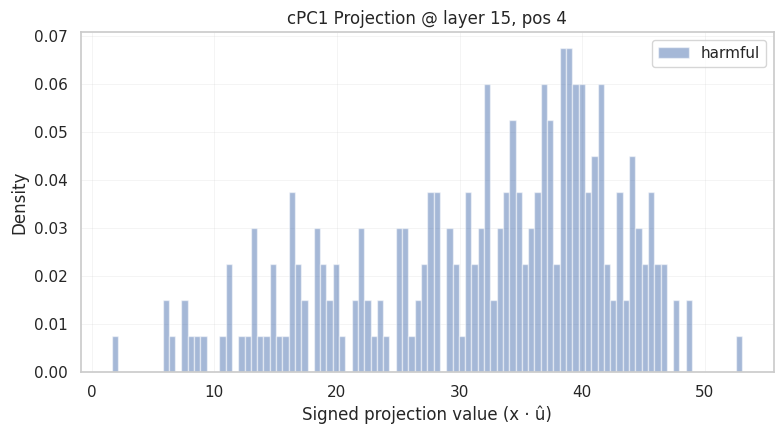

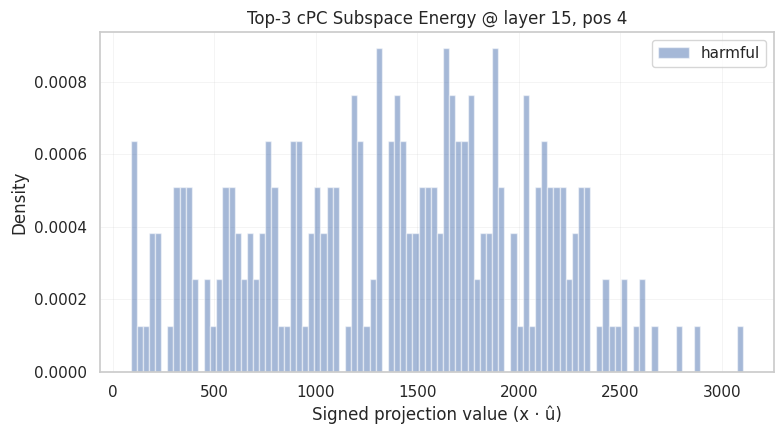

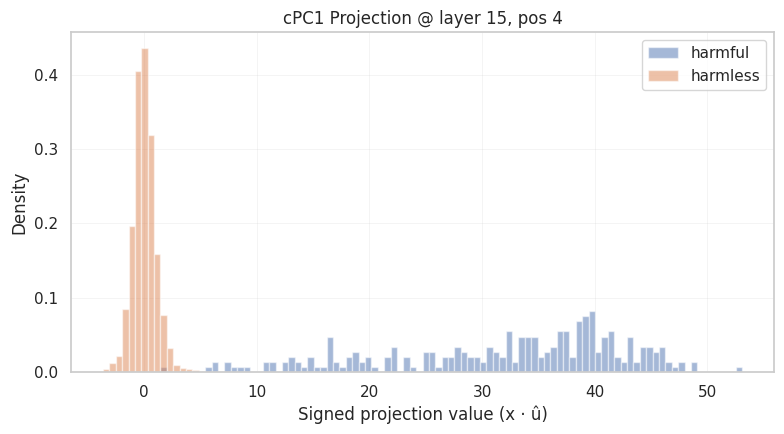

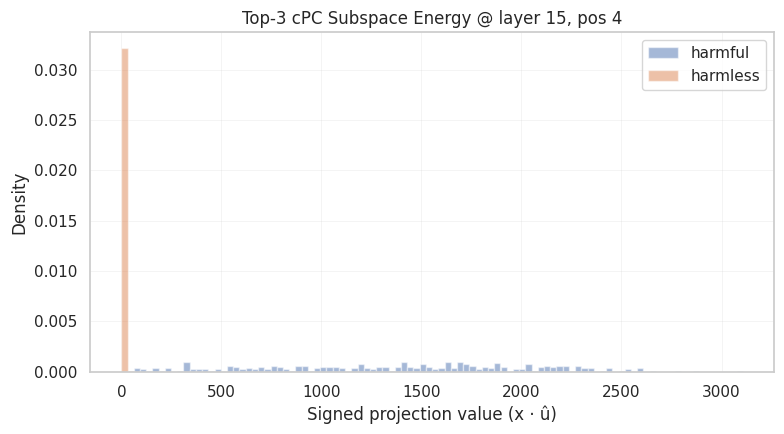

Harmful projection onto cPC1 mean: 32.01274584006139  std: 10.630623850822998
Harmless projection onto cPC1 mean: -1.3500311979441903e-16  std: 0.9994998749374614
Projection AUC: 0.9998
Harmful Top3 Subspace Energy: 1389.0225076503993  std: 673.7271426121272
Harmless Top3 Subspace Energy: 2.997000000000002  std: 3.592405896128238
Energy AUC: 1.0


In [306]:
#first time run
#lb_cpca_layer, lb_cpca_pos, lb_cpca_res = run_cpca(lb_hf_stack, lb_hl_stack, topk = 3)

#run with saved res
lb_cpca_layer, lb_cpca_pos, lb_cpca_res = run_cpca(lb_hf_stack, lb_hl_stack, topk = 3, res = lb_cpca_res, layer = lb_cpca_layer, pos = lb_cpca_pos, compare_hl = True)

### whitening debugging

In [142]:
res = mix_cpca_res
m = 3

# 1) Internal consistency: scores via whitened space vs back-mapped components must match elementwise
Zb = ((mix_Xb - res["mu_b"]) @ res["V_b"]) * (res["var_b"] + 1e-6).rsqrt()   # [N_b, r_b]
Zt = ((mix_Xt - res["mu_b"]) @ res["V_b"]) * (res["var_b"] + 1e-6).rsqrt()   # [N_t, r_b]
Sb1 = Zb @ res["Vz"][:, :m]                                               # [N_b, m]
St1 = Zt @ res["Vz"][:, :m]                                               # [N_t, m]

Sb2 = (mix_Xb - res["mu_b"]) @ res["components"][:, :m]                       # [N_b, m]
St2 = (mix_Xt - res["mu_b"]) @ res["components"][:, :m]                       # [N_t, m]

print("max|Sb1-Sb2|", (Sb1 - Sb2).abs().max().item())
print("max|St1-St2|", (St1 - St2).abs().max().item())
# Expect ~1e-10 to 1e-6. If not, your C or mu_b is inconsistent with whitening.


max|Sb1-Sb2| 5.680804754781832e-05
max|St1-St2| 0.0002738627703351426


In [143]:
# 2) Background calibration: after whitening, background scores should be N(0, I) in aggregate
print("bg mean, std (pc1):", Sb1[:,0].mean().item(), Sb1[:,0].std(unbiased=True).item())
Eb = (Sb1**2).sum(dim=1)
print("bg energy: mean,std:", Eb.mean().item(), Eb.std(unbiased=True).item())
# Expect mean≈0, std≈1 for pc1; and energy mean≈m, std≈sqrt(2m).


bg mean, std (pc1): 2.7355895326763857e-16 0.9999943546468304
bg energy: mean,std: 2.996964578182426 5.9835169008506135


In [144]:
# 3) Denominator health check (is ratio inflated by tiny background variance?)
v1 = res["components"][:, 0]
vb_var = ((mix_Xb - res["mu_b"]) @ v1).var(unbiased=True).item()
vt_var = ((mix_Xt - res["mu_b"]) @ v1).var(unbiased=True).item()
print("var_b along cPC1 ~", vb_var, " | var_t along cPC1 ~", vt_var)
# In ideal whitening, vb_var ≈ 1. If ≪ 1 or ≫ 1, adjust eps/floor (see below).


var_b along cPC1 ~ 0.9999999999999999  | var_t along cPC1 ~ 69.5695243369526


## llama 3.1 8b instruct

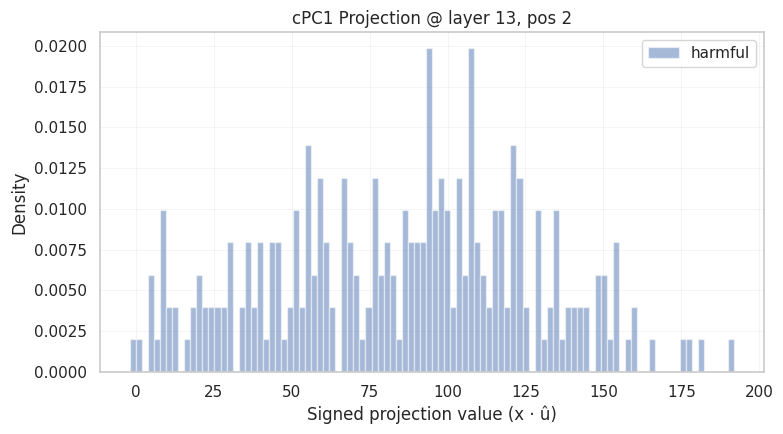

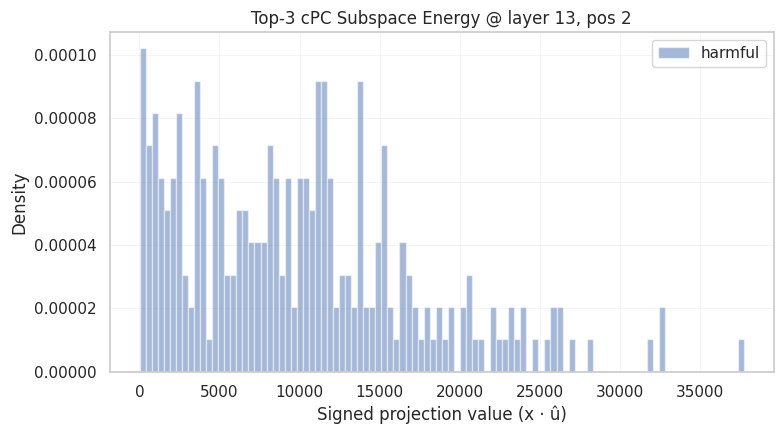

Harmful projection onto cPC1 mean: 85.14114787384858  std: 41.6132642603599
Harmless projection onto cPC1 mean: 1.8118839761882554e-16  std: 0.999499874937461
Projection AUC: 0.9961307692307693
Harmful Top3 Subspace Energy: 9935.016561944569  std: 7320.372669604656
Harmless Top3 Subspace Energy: 2.997  std: 3.8675474362171784
Energy AUC: 0.9999807692307693


In [273]:
# first time run
# li_cpca_layer, li_cpca_pos, li_cpca_res = run_cpca(li_hf_stack, li_hl_stack, topk = 3)

li_cpca_layer, li_cpca_pos, li_cpca_res = run_cpca(li_hf_stack, li_hl_stack, topk = 3, res = li_cpca_res, layer = li_cpca_layer, pos= li_cpca_pos)

## oss 20b

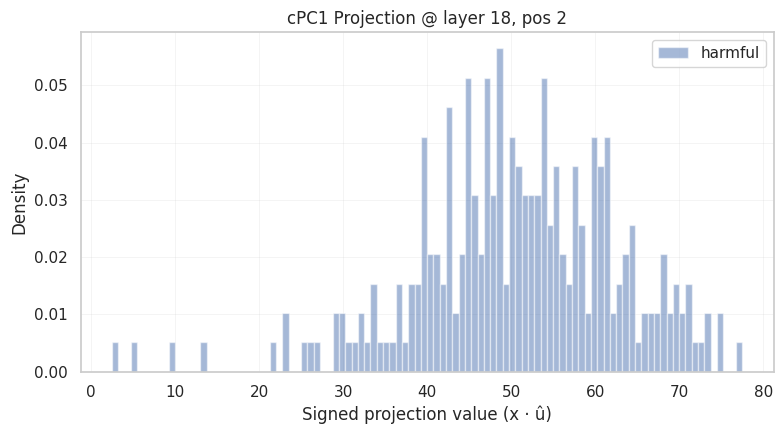

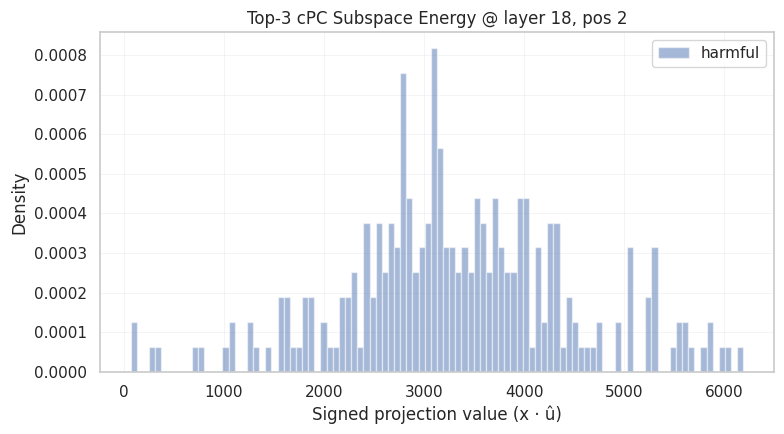

Harmful projection onto cPC1 mean: 50.562967206450445  std: 12.205011559577615
Harmless projection onto cPC1 mean: -1.6697754290362354e-16  std: 0.999499874937461
Projection AUC: 0.9999461538461538
Harmful Top3 Subspace Energy: 3319.1788284758245  std: 1128.670258599823
Harmless Top3 Subspace Energy: 2.9970000000000003  std: 3.057506848246336
Energy AUC: 1.0


In [274]:
# first time run
# oss_cpca_layer, oss_cpca_pos, oss_cpca_res = run_cpca(oss_hf_stack, oss_hl_stack, topk = 3)

oss_cpca_layer, oss_cpca_pos, oss_cpca_res = run_cpca(oss_hf_stack, oss_hl_stack, topk = 3, res = oss_cpca_res, layer = oss_cpca_layer, pos = oss_cpca_pos)

## mixtral8x7b instruct

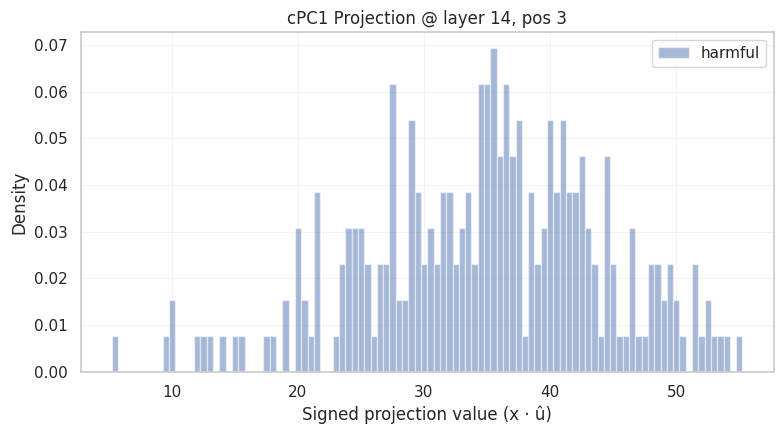

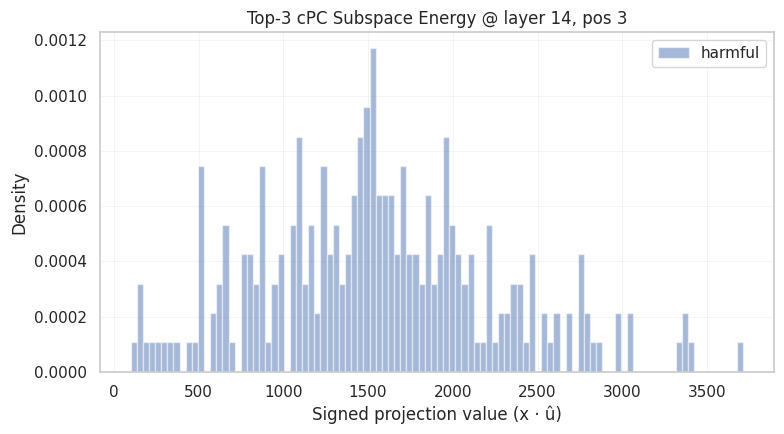

Harmful projection onto cPC1 mean: 34.80397426766635  std: 9.41471502804559
Harmless projection onto cPC1 mean: -2.6645352591003756e-17  std: 0.999499874937461
Projection AUC: 0.9999923076923077
Harmful Top3 Subspace Energy: 1558.6534050693292  std: 687.3417531920052
Harmless Top3 Subspace Energy: 2.9970000000000003  std: 4.175762704773942
Energy AUC: 1.0


In [275]:
# first time run
# mix_cpca_layer, mix_cpca_pos, mix_cpca_res = run_cpca(mix_hf_stack, mix_hl_stack, topk = 3)

mix_cpca_layer, mix_cpca_pos, mix_cpca_res = run_cpca(mix_hf_stack, mix_hl_stack, topk = 3, res = mix_cpca_res, layer = mix_cpca_layer, pos = mix_cpca_pos)

## cPCA arditi comparison

In [210]:
import torch
from typing import Dict, Optional

@torch.no_grad()
def _inv_sqrt(var: torch.Tensor, eps: float = 1e-6):
    return (var + eps).rsqrt()

@torch.no_grad()
def to_whitened_vec(w: torch.Tensor, Vb: torch.Tensor, var_b: torch.Tensor, eps: float = 1e-6):
    """
    Map an original-space vector w [H] into whitened coords: w̃ = W^T w
    where W = Vb diag(1/sqrt(var_b+eps)).
    Returns w̃ with shape [r_keep].
    """
    return (Vb.T @ w) * _inv_sqrt(var_b, eps)

@torch.no_grad()
def compare_arditi_vs_cpca_whitened(
    res: Dict,                             # output dict from your cpca_whitened_* (for chosen layer,pos)
    w_arditi: torch.Tensor,                # [H] original-space Arditi refusal direction
    Xb_eval: Optional[torch.Tensor] = None,# [N_b,H] harmless eval activations (optional; for bg calibration check)
    k: int = 3,                            # top-k subspace to compare against
    eps: float = 1e-6,
    align_to_cpc1: bool = True            # if True, flip Arditi sign so cos with cPC1 is positive
) -> Dict:
    """
    Returns a dictionary with key comparison metrics in the whitened geometry.
    """
    # Pull whitened cPCA pieces
    Vb: torch.Tensor   = res["V_b"]        # [H, r_keep]
    var_b: torch.Tensor= res["var_b"]      # [r_keep]
    Vz: torch.Tensor   = res["Vz"]         # [r_keep, r_z] (columns = whitened cPCs u_j)
    lam: torch.Tensor  = res["lam"].to(torch.float64)  # [r_z] Rayleigh ratios
    mu_b: torch.Tensor = res["mu_b"].to(torch.float64) # [H]

    # Map Arditi vector into whitened coords
    w = w_arditi.to(torch.float64)
    w_tilde = to_whitened_vec(w, Vb, var_b, eps=eps)          # [r_keep]

    # Optional: align sign to make cos with cPC1 positive (purely for readability)
    if align_to_cpc1:
        sgn = torch.sign((Vz[:, 0] * w_tilde).sum())
        if sgn < 0:
            w_tilde = -w_tilde

    # Coefficients of w̃ on the whitened cPC basis (u_j columns of Vz)
    # coeffs[j] = u_j^T w̃
    coeffs = Vz.T @ w_tilde                                  # [r_z], i.e. projection of arditi onto cPCA basis

    # ---- Metrics ----
    # 1) Cb-metric cosine between Arditi and cPC1 (equals whitened cosine)
    cos_cb_cpc1 = float(coeffs[0] / (w_tilde.norm() + 1e-12))

    # 2) Fraction of Arditi's Cb-energy captured by top-k subspace:
    k_use = min(k, coeffs.shape[0])
    num_energy_k = (coeffs[:k_use]**2).sum() 
    den_energy   = (w_tilde.norm()**2).clamp_min(1e-12)
    frac_cb_energy_k = float((num_energy_k / den_energy).item())

    # 3) Fraction of total contrastive variance (trace) captured by Arditi:
    tr_contrastive = lam.clamp_min(0).sum().clamp_min(1e-12) #sum all eigenvalues
    num_trace = (lam * (coeffs**2)).sum() / (coeffs**2).sum().clamp_min(1e-12) #take weighted sum of arditi projection
    phi_trace = float((num_trace / tr_contrastive).item()) #weighted sum of projection/ all eigenvalues = prop of total eigenvalues found in projection

    # 4) Of Arditi's own contrastive energy, how much is in top-k?
    #    sum_{j<=k} λ_j (u_j^T w̃)^2 / sum_j λ_j (u_j^T w̃)^2
    den_w_contrastive = (lam * (coeffs**2)).sum().clamp_min(1e-12)
    num_w_contrastive_k = (lam[:k_use] * (coeffs[:k_use]**2)).sum()
    phi_k = float((num_w_contrastive_k / den_w_contrastive).item())

    # Optional harmless calibration diagnostics on current eval set
    diag = {}
    if Xb_eval is not None:
        Xb_eval = Xb_eval.to(torch.float64)
        inv_s = _inv_sqrt(var_b, eps)
        Zb = ((Xb_eval - mu_b) @ Vb) * inv_s                  # whitened harmless
        # pc1 score stats
        sb1 = Zb @ Vz[:, 0]
        Eb_k = (Zb @ Vz[:, :k_use])**2
        Eb_k = Eb_k.sum(dim=1)
        diag = {
            "bg_pc1_mean": float(sb1.mean().item()),
            "bg_pc1_std":  float(sb1.std(unbiased=True).item()),
            "bg_energy_k_mean": float(Eb_k.mean().item()),
            "bg_energy_k_std":  float(Eb_k.std(unbiased=True).item()),
        }

    return {
        "cos_cb_cpc1": cos_cb_cpc1,                  # Cb-metric cosine with cPC1
        "frac_cb_energy_k": frac_cb_energy_k,        # fraction of Arditi energy inside top-k subspace
        "phi_trace": phi_trace,                      # share of total contrastive variance captured by Arditi
        "phi_k": phi_k,                              # share of Arditi's own contrastive energy captured by top-k
        "coeffs": coeffs.cpu().numpy(),              # u_j^T w̃ (for plotting loadings)
        "lam": lam.cpu().numpy(),                    # Rayleigh ratios
        "diagnostics_bg": diag,
    }


In [234]:
def cpca_arditi_compare_run(mean_diff_loc, cpca_pos, cpca_layer, cpca_res, arditi_meta, arditi_dir, hf_stack, hl_stack):
    mean_diff = torch.load(mean_diff_loc,
                          map_location=torch.device('cpu'))
    cpca_dir = mean_diff[cpca_pos][cpca_layer]
    cpca_arditi = compare_arditi_vs_cpca_whitened(cpca_res, cpca_dir)
    print("cpca layer/pos",
          "\ncos:", cpca_arditi['cos_cb_cpc1'], 
          "\nfrac_energy:", cpca_arditi['frac_cb_energy_k'], 
          "\nphi_trace:", cpca_arditi['phi_trace'],
          #"\nphi_k:", lb_cpca_arditi['phi_k']
         )
    
    arditi_Xt, arditi_Xb = get_lp_slices(hf_stack, hl_stack, arditi_meta[1], arditi_meta[0])
    arditi_res = cpca_whitened(arditi_Xt, arditi_Xb)
    arditi_cpca = compare_arditi_vs_cpca_whitened(arditi_res, arditi_dir)
    print("arditi layer/pos",
          "\ncos:", arditi_cpca['cos_cb_cpc1'], 
          "\nfrac_energy:", arditi_cpca['frac_cb_energy_k'], 
          "\nphi_trace:", arditi_cpca['phi_trace'],
         # "\nphi_k:", arditi_cpca['phi_k']
         )
    return cpca_arditi, arditi_cpca

## arditi compare results

In [237]:
lb_cpca_arditi, lb_arditi_cpca = cpca_arditi_compare_run("/media/anna/Samsung_T5/alignment/runs/Meta-Llama-3.1-8B/generate_directions/mean_diffs.pt",
                                                      lb_cpca_pos, lb_cpca_layer, lb_cpca_res, 
                                                      lb_meta, lb_dir, 
                                                      lb_hf_stack, lb_hl_stack)

/tmp/ipykernel_3118179/3289743793.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mean_diff = torch.load(mean_diff_loc,


cpca layer/pos 
cos: 0.7803842792805036 
frac_energy: 0.6253957435053417 
phi_trace: 0.3391501793507168
arditi layer/pos 
cos: 0.8233474391315012 
frac_energy: 0.6873080335629693 
phi_trace: 0.4049350738149956


In [238]:
li_cpca_arditi, li_arditi_cpca = cpca_arditi_compare_run("/media/anna/Samsung_T5/alignment/runs/Meta-Llama-3.1-8B-Instruct/generate_directions/mean_diffs.pt",
                                                      li_cpca_pos, li_cpca_layer, li_cpca_res, 
                                                      li_meta, li_dir, 
                                                      li_hf_stack, li_hl_stack)


/tmp/ipykernel_3118179/3289743793.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mean_diff = torch.load(mean_diff_loc,


cpca layer/pos 
cos: 0.8028389750233216 
frac_energy: 0.6533301974775255 
phi_trace: 0.5413630752145765
arditi layer/pos 
cos: 0.8999965387522304 
frac_energy: 0.8801110257754066 
phi_trace: 0.39373723810279354


In [239]:
oss_cpca_arditi, oss_arditi_cpca = cpca_arditi_compare_run("/media/anna/Samsung_T5/alignment/runs/gpt-oss-20b/generate_directions/mean_diffs.pt",
                                                      oss_cpca_pos, oss_cpca_layer, oss_cpca_res, 
                                                      oss_meta, oss_dir, 
                                                      oss_hf_stack, oss_hl_stack)


/tmp/ipykernel_3118179/3289743793.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mean_diff = torch.load(mean_diff_loc,


cpca layer/pos 
cos: 0.9937712650906768 
frac_energy: 0.9895404261087287 
phi_trace: 0.5484231643953538
arditi layer/pos 
cos: 0.9503086420990191 
frac_energy: 0.9109835595138247 
phi_trace: 0.1617175017249948


In [240]:
mix_cpca_arditi, mix_arditi_cpca = cpca_arditi_compare_run("/media/anna/Samsung_T5/alignment/runs/Mixtral-8x7B-Instruct-v0.1/generate_directions/mean_diffs.pt",
                                                      mix_cpca_pos, mix_cpca_layer, mix_cpca_res, 
                                                      mix_meta, mix_dir, 
                                                      mix_hf_stack, mix_hl_stack)


/tmp/ipykernel_3118179/3289743793.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mean_diff = torch.load(mean_diff_loc,


cpca layer/pos 
cos: 0.9406949151934874 
frac_energy: 0.9126275853566718 
phi_trace: 0.48787463976965173
arditi layer/pos 
cos: 0.9616826355067576 
frac_energy: 0.9417747131099891 
phi_trace: 0.524156397644903


# PLS

In [ ]:
# ===== PLS per-slice with alt_score-style selection =====
import os
from pathlib import Path
from typing import Dict, Tuple, List, Optional

import numpy as np
import torch
import torch.nn.functional as F
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# ---------- Utilities ----------
def _to_numpy(x: torch.Tensor) -> np.ndarray:
    return x.detach().cpu().numpy()

def class_balanced_weights(y: np.ndarray) -> np.ndarray:
    """
    Balance 0/1 labels to contribute ~equally to the loss.
    """
    y = y.astype(int)
    p1 = y.mean()
    p0 = 1 - p1
    w1 = 0.5 / max(p1, 1e-12)
    w0 = 0.5 / max(p0, 1e-12)
    return np.where(y == 1, w1, w0)

def stdspace_to_original(vec_std: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """
    Map vector from standardized feature space back to original space.
    """
    return vec_std / (scaler.scale_ + 1e-12)

def cosine(a: np.ndarray, b: np.ndarray) -> float:
    a_n = np.linalg.norm(a); b_n = np.linalg.norm(b)
    if a_n == 0 or b_n == 0:
        return 0.0
    return float(a.dot(b) / (a_n * b_n))


# ---------- Core PLS fitting (for one feature matrix X, no aggregation) ----------
def fit_pls_cv(
    X: np.ndarray,               # [N, D] original features for THIS (layer,pos)
    y: np.ndarray,               # [N] in {0,1}
    n_components_grid: List[int] = [1, 2, 3, 5, 8],
    n_splits: int = 5,
    random_state: int = 0,
    use_class_weights: bool = True,
) -> Dict:
    """
    Standardizes X within folds, picks best n_components by mean CV ROC-AUC, and refits on all data.
    Returns: scaler, pls, best_k, best_cv_auc, x_weights/loadings/coef in std-space.
    """
    assert X.ndim == 2
    y = y.astype(np.float32)
    N, D = X.shape

    # cap grid to feasible ranks
    n_grid = [max(1, min(k, D, N - 1)) for k in n_components_grid]
    n_grid = sorted(set(n_grid))

    w = class_balanced_weights(y) if use_class_weights else None
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    best_auc, best_k = -np.inf, None
    cv_curve = []

    for k in n_grid:
        aucs = []
        for tr, va in skf.split(X, y):
            Xtr, Xva = X[tr], X[val]
            ytr, yva = y[tr], y[va]
            wtr = w[tr] if w is not None else None

            scaler = StandardScaler(with_mean=True, with_std=True)
            Xtr_s = scaler.fit_transform(Xtr)
            Xva_s = scaler.transform(Xva)

            pls = PLSRegression(n_components=k, scale=False)
            pls.fit(Xtr_s, ytr.reshape(-1, 1), sample_weight=wtr)

            yhat = pls.predict(Xva_s).ravel()
            aucs.append(roc_auc_score(yva, yhat))

        mean_auc = float(np.mean(aucs))
        cv_curve.append({"n_components": k, "cv_auc": mean_auc})
        if mean_auc > best_auc:
            best_auc, best_k = mean_auc, k

    # Refit on all data with best_k
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xs = scaler.fit_transform(X)
    pls = PLSRegression(n_components=best_k, scale=False)
    pls.fit(Xs, y.reshape(-1, 1), sample_weight=w)

    return {
        "scaler": scaler,
        "pls": pls,
        "best_k": best_k,
        "best_cv_auc": best_auc,
        "cv_curve": cv_curve,
        "x_weights_stdspace": pls.x_weights_.copy(),   # [D, best_k]
        "x_loadings_stdspace": pls.x_loadings_.copy(),
        "coef_stdspace": pls.coef_.copy().ravel(),     # [D]
    }


# ---------- alt_score analogue (Rayleigh ratio + 0.1 * mean gap) ----------
def pls_alt_score(pls_res: Dict, X: np.ndarray, y: np.ndarray) -> float:
    """
    X, y are for a SINGLE (layer,pos) slice. X is in ORIGINAL feature space (pre-standardization).
    """
    w1_std = pls_res["x_weights_stdspace"][:, 0]                 # first PLS weight in std space
    w1 = stdspace_to_original(w1_std, pls_res["scaler"])          # back to original space
    t = X @ w1                                                    # 1D projections

    Xt = t[y == 1]
    Xb = t[y == 0]
    if len(Xt) < 2 or len(Xb) < 2:
        # fallback if a fold/sample selection corner case appears
        return float("-inf")

    var_t = np.var(Xt, ddof=1)
    var_b = np.var(Xb, ddof=1)
    mean_t = float(np.mean(Xt))
    mean_b = float(np.mean(Xb))

    rr = (var_t + 1e-12) / (var_b + 1e-12)                        # Rayleigh-style variance ratio
    mg = (mean_t - mean_b)                                        # mean gap along component
    return float(rr + 0.1 * mg)


# ---------- Main runner: fit one PLS per (layer, pos), score, and rank ----------
def run_pls_all_slices(
    X_lpnh: torch.Tensor,       # [L, P, N, H]
    y: np.ndarray,              # [N] in {0,1}
    n_components_grid: List[int] = [1, 2, 3, 5, 8],
    n_splits: int = 5,
) -> Dict[Tuple[int, int], Dict]:
    """
    Returns a dict keyed by (layer_idx, pos_idx) with:
      - alt_score
      - best_cv_auc
      - best_k
      - first_dir_orig: np.ndarray [H], first PLS direction in ORIGINAL H-dim space
      - coef_orig: np.ndarray [H], regression vector in ORIGINAL space
      - cv_curve
    No aggregation across slices—each slice is X = X_lpnh[li, pi, :, :] -> [N, H].
    """
    L, P, N, H = X_lpnh.shape
    out: Dict[Tuple[int, int], Dict] = {}

    for li in range(L):
        for pi in range(P):
            X_slice = _to_numpy(X_lpnh[li, pi])    # [N, H] (original space here means pre-standardization)
            pls_res = fit_pls_cv(
                X_slice, y,
                n_components_grid=n_components_grid,
                n_splits=n_splits
            )
            # back-map weights/coef to original feature space
            first_dir_orig = stdspace_to_original(pls_res["x_weights_stdspace"][:, 0], pls_res["scaler"])
            coef_orig = stdspace_to_original(pls_res["coef_stdspace"], pls_res["scaler"])

            alt = pls_alt_score(pls_res, X_slice, y)
            out[(li, pi)] = {
                "alt_score": alt,
                "best_cv_auc": pls_res["best_cv_auc"],
                "best_k": pls_res["best_k"],
                "first_dir_orig": first_dir_orig,   # R^H
                "coef_orig": coef_orig,             # R^H
                "cv_curve": pls_res["cv_curve"],
            }
    return out


# ---------- Helpers to inspect / select ----------
def rank_by_alt_score(results: Dict[Tuple[int, int], Dict], top_k: int = 10):
    ranked = sorted(results.items(), key=lambda kv: kv[1]["alt_score"], reverse=True)
    return ranked[:top_k]

def select_best_slice(results: Dict[Tuple[int, int], Dict]) -> Tuple[Tuple[int, int], Dict]:
    return max(results.items(), key=lambda kv: kv[1]["alt_score"])


# ---------- Projection utilities for downstream analysis ----------
def project_scores_1d(direction_orig: np.ndarray, X_new: np.ndarray) -> np.ndarray:
    """
    Project new samples onto a 1D direction in ORIGINAL space.
    direction_orig: [H]
    X_new: [N, H]
    """
    return X_new @ direction_orig

def compare_with_direction(pls_dir: np.ndarray, other_dir: np.ndarray) -> float:
    """Cosine similarity between PLS direction and another (e.g., Arditi) direction."""
    return cosine(pls_dir, other_dir)


In [ ]:
# combine harmless and harmful datasets and create 0/1 labels



# 2) Run PLS per-slice (no aggregation)
results = run_pls_all_slices(X_lpnh, y, n_components_grid=[1,2,3,5,8], n_splits=5)

# 3) Rank and inspect
top = rank_by_alt_score(results, top_k=10)
print("Top slices by alt_score:")
for (li, pi), meta in top:
    print(f"  Layer idx {li}, pos {pi}: alt={meta['alt_score']:.3f}, AUC={meta['best_cv_auc']:.3f}, k={meta['best_k']}")

# 4) Best slice + its direction in ORIGINAL H-dim space
(best_li, best_pi), best_meta = select_best_slice(results)
best_dir = best_meta["first_dir_orig"]   # shape [H]


In [204]:
#garbage collect models after running
import gc

for name in ["lb_hf_stack_norm", "li_hf", "lb_hl_stack_norm", "li_hl"]:
    if name in globals():
        del globals()[name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()